## 1 — Imports & Setup

In [1]:
!pip install wfdb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.1 MB/s eta 0:00:00


In [2]:
import os, time, gc, warnings, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import wilcoxon
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

In [3]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, Dense, Dropout, Add, Activation, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f'TensorFlow {tf.__version__}')
print(f'GPUs: {tf.config.list_physical_devices("GPU")}')

TensorFlow 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2 — Configuration

In [4]:
# ── Dataset ───────────────────────────────────────────────────────────────────
DATA_DIR = r"/kaggle/input/datasets/rracer17/mit-bih-mitdb/mit-bih-arrhythmia-database-1.0.0"

# ── Paper constants ──────────────────────────────────────────────────────────
FS           = 360
TOTAL_STEPS  = 100_000
TRAIN_STEPS  = 40_000
VAL_STEPS    = 10_000
TEST_STEPS   = 50_000
LOOKBACK     = 10
HORIZON      = 10

# ── Auto-discover ALL patients in MIT-BIH dataset ─────────────────────────
PATIENTS = sorted(set(
    os.path.splitext(os.path.basename(f))[0]
    for f in glob.glob(os.path.join(DATA_DIR, '*.hea'))
))
print(f'Discovered {len(PATIENTS)} patients: {PATIENTS}')

# ┌──────────────────────────────────────────────────────────────────────────┐
# │  MOGWO-OPTIMIZED HYPERPARAMETERS                                       │
# │  Source: MOGWO Pareto-best (Eval 28), pilot RMSE = 0.026148            │
# │  Search: 5 wolves × 5 iters = 30 evals, 5 pilot patients, H=10       │
# └──────────────────────────────────────────────────────────────────────────┘
NUM_FILTERS   = 128
DROPOUT_RATE  = 0.131
LEARNING_RATE = 0.00451
NUM_BLOCKS    = 3     # RF = 29 ≫ lookback=10
KERNEL_SIZE   = 3
BATCH_SIZE    = 128

# ── Training ─────────────────────────────────────────────────────────────────
EPOCHS   = 200
PATIENCE = 50

# ── Output ───────────────────────────────────────────────────────────────────
OUT_DIR   = '/kaggle/working'
PLOT_DIR  = os.path.join(OUT_DIR, 'plots_new_set')
CSV_NAME  = os.path.join(OUT_DIR, 'tcn_mo_mogwo_new_set_results.csv')
os.makedirs(PLOT_DIR, exist_ok=True)

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── 10 random patients for signal visualization ──────────────────────────────
VIZ_PATIENTS = sorted(np.random.choice(PATIENTS, size=min(10, len(PATIENTS)),
                                       replace=False).tolist())

print(f'\nConfig    : MOGWO-Optimized (NEW_SET)')
print(f'Patients  : {len(PATIENTS)} (all MIT-BIH)')
print(f'Viz sample: {len(VIZ_PATIENTS)} → {VIZ_PATIENTS}')
print(f'Horizon   : H={HORIZON}')
print(f'TCN       : blocks={NUM_BLOCKS}, filters={NUM_FILTERS}, kernel={KERNEL_SIZE}')
print(f'Dropout   : {DROPOUT_RATE}')
print(f'Training  : epochs={EPOCHS}, patience={PATIENCE}, batch={BATCH_SIZE}, lr={LEARNING_RATE}')

Discovered 48 patients: ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']

Config    : MOGWO-Optimized (NEW_SET)
Patients  : 48 (all MIT-BIH)
Viz sample: 10 → ['104', '113', '121', '201', '202', '203', '205', '219', '222', '230']
Horizon   : H=10
TCN       : blocks=3, filters=128, kernel=3
Dropout   : 0.131
Training  : epochs=200, patience=50, batch=128, lr=0.00451


In [5]:
# ┌──────────────────────────────────────────────────────────────────────────┐
# │  PREVIOUS GWO RESULTS (hardcoded for comparison, 21 patients only)     │
# │  Source: Final_Optimized.ipynb (256 filters, 4 blocks)                 │
# └──────────────────────────────────────────────────────────────────────────┘
GWO_RESULTS = {
    '100': {'RMSE': 0.026111, 'MAE': 0.012896, 'R2': 0.926181},
    '101': {'RMSE': 0.063896, 'MAE': 0.021736, 'R2': 0.662033},
    '102': {'RMSE': 0.028617, 'MAE': 0.011196, 'R2': 0.820800},
    '103': {'RMSE': 0.017083, 'MAE': 0.008118, 'R2': 0.978319},
    '104': {'RMSE': 0.051275, 'MAE': 0.027296, 'R2': 0.757826},
    '105': {'RMSE': 0.037569, 'MAE': 0.015648, 'R2': 0.893831},
    '106': {'RMSE': 0.033945, 'MAE': 0.012149, 'R2': 0.867732},
    '107': {'RMSE': 0.030133, 'MAE': 0.012627, 'R2': 0.947614},
    '108': {'RMSE': 0.044255, 'MAE': 0.022964, 'R2': 0.761901},
    '109': {'RMSE': 0.015569, 'MAE': 0.008351, 'R2': 0.987155},
    '112': {'RMSE': 0.037540, 'MAE': 0.017670, 'R2': 0.893188},
    '113': {'RMSE': 0.020109, 'MAE': 0.007351, 'R2': 0.975835},
    '114': {'RMSE': 0.012897, 'MAE': 0.005108, 'R2': 0.960552},
    '115': {'RMSE': 0.028135, 'MAE': 0.009273, 'R2': 0.889324},
    '116': {'RMSE': 0.034155, 'MAE': 0.013012, 'R2': 0.930015},
    '117': {'RMSE': 0.029724, 'MAE': 0.015109, 'R2': 0.941696},
    '119': {'RMSE': 0.019647, 'MAE': 0.007742, 'R2': 0.969373},
    '121': {'RMSE': 0.024997, 'MAE': 0.011903, 'R2': 0.959717},
    '122': {'RMSE': 0.020536, 'MAE': 0.010791, 'R2': 0.964415},
    '123': {'RMSE': 0.020861, 'MAE': 0.007468, 'R2': 0.885420},
    '124': {'RMSE': 0.026718, 'MAE': 0.012289, 'R2': 0.969546},
}

GWO_PATIENT_IDS = sorted(GWO_RESULTS.keys())
df_gwo = pd.DataFrame([
    {'Patient': pid, **vals} for pid, vals in GWO_RESULTS.items()
]).sort_values('Patient').reset_index(drop=True)

print(f'Previous GWO results: {len(df_gwo)} patients (256 filters / 4 blocks)')
print(f'  Mean RMSE = {df_gwo.RMSE.mean():.6f}')
print(f'  Mean R²   = {df_gwo.R2.mean():.4f}')

Previous GWO results: 21 patients (256 filters / 4 blocks)
  Mean RMSE = 0.029703
  Mean R²   = 0.9020


## 3 — Data Pipeline

In [6]:
def load_ecg_signal(record_id, data_dir, n_steps=100_000):
    """Load MLII lead from MIT-BIH, truncate/pad to n_steps."""
    path = os.path.join(data_dir, record_id)
    rec  = wfdb.rdrecord(path)
    sig_names_upper = [s.upper() for s in rec.sig_name]
    ch = sig_names_upper.index('MLII') if 'MLII' in sig_names_upper else 0
    signal = rec.p_signal[:, ch].astype(np.float32)
    if len(signal) < n_steps:
        pad = np.full(n_steps - len(signal), signal[-1], dtype=np.float32)
        signal = np.concatenate([signal, pad])
    return signal[:n_steps]


def preprocess_patient(signal, train_steps=40_000, val_steps=10_000):
    """Split → train/val/test, MinMax-normalise (fit on train only)."""
    train_end = train_steps
    val_end   = train_steps + val_steps
    train_raw = signal[:train_end]
    val_raw   = signal[train_end:val_end]
    test_raw  = signal[val_end:]
    scaler     = MinMaxScaler(feature_range=(0, 1))
    train_norm = scaler.fit_transform(train_raw.reshape(-1, 1)).flatten()
    val_norm   = scaler.transform(val_raw.reshape(-1, 1)).flatten()
    test_norm  = scaler.transform(test_raw.reshape(-1, 1)).flatten()
    return train_norm, val_norm, test_norm, scaler


def make_multistep_sequences(signal, lookback, horizon):
    """X = lookback window, y = next H steps (Multi-Output)."""
    X, y = [], []
    for i in range(len(signal) - lookback - horizon + 1):
        X.append(signal[i : i + lookback])
        y.append(signal[i + lookback : i + lookback + horizon])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def compute_metrics(y_true, y_pred):
    yt, yp = y_true.flatten(), y_pred.flatten()
    return {
        'RMSE': float(np.sqrt(mean_squared_error(yt, yp))),
        'MAE':  float(mean_absolute_error(yt, yp)),
        'R2':   float(r2_score(yt, yp)),
    }


def compute_per_step_metrics(y_true, y_pred):
    rows = []
    for h in range(y_true.shape[1]):
        m = compute_metrics(y_true[:, h], y_pred[:, h])
        m['Step'] = h + 1
        rows.append(m)
    return pd.DataFrame(rows)


print('Data pipeline defined.')

Data pipeline defined.


In [7]:
# ── Load ALL patients ─────────────────────────────────────────────────────────
patient_signals = {}

print(f'Loading {len(PATIENTS)} patients...\n')
for rid in tqdm(PATIENTS, desc='Patients'):
    signal = load_ecg_signal(rid, DATA_DIR, n_steps=TOTAL_STEPS)
    tr, vl, te, sc = preprocess_patient(signal, TRAIN_STEPS, VAL_STEPS)
    patient_signals[rid] = {'train': tr, 'val': vl, 'test': te, 'scaler': sc}
    tqdm.write(f'  Patient {rid:>3s} | train={len(tr):,}  val={len(vl):,}  test={len(te):,}')

print(f'\nAll {len(patient_signals)} patients loaded.')

Loading 48 patients...



Patients:   0%|          | 0/48 [00:00<?, ?it/s]

  Patient 100 | train=40,000  val=10,000  test=50,000
  Patient 101 | train=40,000  val=10,000  test=50,000
  Patient 102 | train=40,000  val=10,000  test=50,000
  Patient 103 | train=40,000  val=10,000  test=50,000
  Patient 104 | train=40,000  val=10,000  test=50,000
  Patient 105 | train=40,000  val=10,000  test=50,000
  Patient 106 | train=40,000  val=10,000  test=50,000
  Patient 107 | train=40,000  val=10,000  test=50,000
  Patient 108 | train=40,000  val=10,000  test=50,000
  Patient 109 | train=40,000  val=10,000  test=50,000
  Patient 111 | train=40,000  val=10,000  test=50,000
  Patient 112 | train=40,000  val=10,000  test=50,000
  Patient 113 | train=40,000  val=10,000  test=50,000
  Patient 114 | train=40,000  val=10,000  test=50,000
  Patient 115 | train=40,000  val=10,000  test=50,000
  Patient 116 | train=40,000  val=10,000  test=50,000
  Patient 117 | train=40,000  val=10,000  test=50,000
  Patient 118 | train=40,000  val=10,000  test=50,000
  Patient 119 | train=40,000

## 4 — Model Architecture

Same residual block as baseline. **n_blocks=3** (MOGWO-justified).  
RF = 1 + 2(3−1)(2³−1) = 29 — still 3× the lookback of 10.  
128 filters instead of 256 — ~50% fewer parameters, comparable accuracy.

In [8]:
def residual_block(x, filters, kernel_size, dilation_rate, dropout_rate):
    out = Conv1D(filters, kernel_size, dilation_rate=dilation_rate, padding='causal')(x)
    out = BatchNormalization()(out)
    out = Activation('relu')(out)
    out = Dropout(dropout_rate)(out)
    out = Conv1D(filters, kernel_size, dilation_rate=dilation_rate, padding='causal')(out)
    out = BatchNormalization()(out)
    out = Activation('relu')(out)
    out = Dropout(dropout_rate)(out)
    if x.shape[-1] != filters:
        x = Conv1D(filters, 1)(x)
    return Add()([x, out])


def build_tcn(lookback, output_size, n_blocks, n_filters, kernel_size, dropout_rate, learning_rate):
    inp = Input(shape=(lookback, 1))
    x = inp
    for i in range(n_blocks):
        x = residual_block(x, n_filters, kernel_size, 2 ** i, dropout_rate)
    x = x[:, -1, :]
    x = Dense(n_filters, activation='relu')(x)
    out = Dense(output_size)(x)
    model = Model(inp, out, name=f'TCN_H{output_size}')
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate), loss='mse')
    return model


# ── Parameter count comparison ────────────────────────────────────────────────
demo_new = build_tcn(LOOKBACK, HORIZON, 3, 128, 3, 0.1, 0.001)
demo_old = build_tcn(LOOKBACK, HORIZON, 4, 256, 3, 0.1, 0.001)
print(f'MOGWO config (3 blocks, 128 filters): {demo_new.count_params():,} params')
print(f'Old GWO      (4 blocks, 256 filters): {demo_old.count_params():,} params')
print(f'Reduction: {(1 - demo_new.count_params()/demo_old.count_params())*100:.1f}%')
del demo_new, demo_old

demo = build_tcn(LOOKBACK, HORIZON, NUM_BLOCKS, NUM_FILTERS, KERNEL_SIZE, DROPOUT_RATE, LEARNING_RATE)
demo.summary()
del demo

I0000 00:00:1786904349.064585      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786904349.067613      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


MOGWO config (3 blocks, 128 filters): 268,042 params
Old GWO      (4 blocks, 256 filters): 1,456,138 params
Reduction: 81.6%


Model: "TCN_H10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 10, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, 10, 128)   │        512 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 128)   │        512 │ conv1d_16[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 10, 128)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 10, 128)   │          0 │ activation_14[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_17 (Conv1D)  │ (None, 10, 128)   │     49,280 │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 128)   │        512 │ conv1d_17[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 10, 128)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, 10, 128)   │        256 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 10, 128)   │          0 │ activation_15[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 10, 128)   │          0 │ conv1d_18[0][0],  │
│                     │                   │            │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_19 (Conv1D)  │ (None, 10, 128)   │     49,280 │ add_7[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 128)   │        512 │ conv1d_19[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 10, 128)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 10, 128)   │          0 │ activation_16[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_20 (Conv1D)  │ (None, 10, 128)   │     49,280 │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 128)   │        512 │ conv1d_20[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_17       │ (None, 10, 128)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 268,042 (1.02 MB)

 Trainable params: 266,506 (1.02 MB)

 Non-trainable params: 1,536 (6.00 KB)

## 5 — Train & Evaluate All Patients

In [9]:
results            = []
per_step_results   = {}
saved_preds        = {}
training_histories = {}

print(f'Running: {len(PATIENTS)} patients × H={HORIZON}')
print(f'Config : blocks={NUM_BLOCKS}, filters={NUM_FILTERS}, kernel={KERNEL_SIZE}, '
      f'dropout={DROPOUT_RATE}, lr={LEARNING_RATE}, batch={BATCH_SIZE}')
print('=' * 80)

for rid in tqdm(PATIENTS, desc='Patients'):
    tf.keras.backend.clear_session()
    gc.collect()

    tr = patient_signals[rid]['train']
    vl = patient_signals[rid]['val']
    te = patient_signals[rid]['test']

    X_tr, y_tr = make_multistep_sequences(tr, LOOKBACK, HORIZON)
    X_vl, y_vl = make_multistep_sequences(vl, LOOKBACK, HORIZON)
    X_te, y_te = make_multistep_sequences(te, LOOKBACK, HORIZON)

    X_tr_r = X_tr.reshape(-1, X_tr.shape[1], 1)
    X_vl_r = X_vl.reshape(-1, X_vl.shape[1], 1)
    X_te_r = X_te.reshape(-1, X_te.shape[1], 1)

    t0 = time.time()
    model = build_tcn(LOOKBACK, HORIZON,
                      NUM_BLOCKS, NUM_FILTERS, KERNEL_SIZE,
                      DROPOUT_RATE, LEARNING_RATE)

    history = model.fit(
        X_tr_r, y_tr,
        validation_data=(X_vl_r, y_vl),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=PATIENCE,
                          restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=25, min_lr=1e-6),
        ],
        verbose=0
    )

    preds = model.predict(X_te_r, batch_size=2048, verbose=0)
    elapsed = time.time() - t0

    m = compute_metrics(y_te, preds)
    m['Time_s'] = round(elapsed, 2)
    m['Epochs_trained'] = len(history.history['loss'])
    results.append({'Patient': rid, 'Horizon': HORIZON, **m})

    per_step_results[rid] = compute_per_step_metrics(y_te, preds)
    saved_preds[rid] = (y_te.copy(), preds.copy())
    training_histories[rid] = {
        'loss': history.history['loss'],
        'val_loss': history.history['val_loss'],
    }

    del model
    gc.collect()

    tqdm.write(
        f'  Patient {rid} | R²={m["R2"]:.4f}  RMSE={m["RMSE"]:.4f}  '
        f'MAE={m["MAE"]:.4f}  ({m["Epochs_trained"]} ep, {elapsed:.1f}s)'
    )

print(f'\nAll {len(results)} patients complete.')

Running: 48 patients × H=10
Config : blocks=3, filters=128, kernel=3, dropout=0.131, lr=0.00451, batch=128


Patients:   0%|          | 0/48 [00:00<?, ?it/s]

I0000 00:00:1786904363.335321      79 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  Patient 100 | R²=0.9258  RMSE=0.0262  MAE=0.0115  (200 ep, 317.2s)
  Patient 101 | R²=0.7765  RMSE=0.0520  MAE=0.0184  (86 ep, 145.5s)
  Patient 102 | R²=0.8307  RMSE=0.0278  MAE=0.0110  (200 ep, 316.5s)
  Patient 103 | R²=0.9767  RMSE=0.0177  MAE=0.0084  (200 ep, 317.7s)
  Patient 104 | R²=0.7460  RMSE=0.0525  MAE=0.0282  (89 ep, 150.4s)
  Patient 105 | R²=0.8922  RMSE=0.0379  MAE=0.0161  (126 ep, 204.6s)
  Patient 106 | R²=0.8510  RMSE=0.0360  MAE=0.0130  (152 ep, 246.8s)
  Patient 107 | R²=0.9440  RMSE=0.0311  MAE=0.0132  (200 ep, 317.7s)
  Patient 108 | R²=0.7592  RMSE=0.0445  MAE=0.0229  (128 ep, 208.1s)
  Patient 109 | R²=0.9856  RMSE=0.0165  MAE=0.0087  (200 ep, 317.8s)
  Patient 111 | R²=0.8982  RMSE=0.0294  MAE=0.0154  (173 ep, 274.4s)
  Patient 112 | R²=0.8852  RMSE=0.0389  MAE=0.0181  (200 ep, 316.4s)
  Patient 113 | R²=0.9728  RMSE=0.0213  MAE=0.0080  (200 ep, 318.2s)
  Patient 114 | R²=0.9525  RMSE=0.0142  MAE=0.0053  (200 ep, 316.1s)
  Patient 115 | R²=0.8713  RMSE=0.03

In [10]:
# ── Save results ─────────────────────────────────────────────────────────────
df_results = pd.DataFrame(results)
df_results.to_csv(CSV_NAME, index=False)
print(f'Results saved to {CSV_NAME}\n')
display(df_results)

print(f'\n--- Summary (H={HORIZON}, {len(PATIENTS)} patients) ---')
print(f'Mean RMSE : {df_results.RMSE.mean():.6f} ± {df_results.RMSE.std():.6f}')
print(f'Mean MAE  : {df_results.MAE.mean():.6f} ± {df_results.MAE.std():.6f}')
print(f'Mean R²   : {df_results.R2.mean():.4f} ± {df_results.R2.std():.4f}')

Results saved to /kaggle/working/tcn_mo_mogwo_new_set_results.csv



,Patient,Horizon,RMSE,MAE,R2,Time_s,Epochs_trained
0,100,10,0.026184,0.011491,0.925768,317.24,200
1,101,10,0.051956,0.018409,0.776535,145.51,86
2,102,10,0.027813,0.011044,0.830733,316.46,200
3,103,10,0.017719,0.008436,0.976675,317.71,200
4,104,10,0.052508,0.028241,0.746041,150.41,89
5,105,10,0.037865,0.016103,0.892151,204.64,126
6,106,10,0.036032,0.012968,0.850964,246.76,152
7,107,10,0.031147,0.013202,0.944028,317.73,200
8,108,10,0.044503,0.022901,0.759224,208.10,128
9,109,10,0.016458,0.008712,0.985647,317.81,200



--- Summary (H=10, 48 patients) ---
Mean RMSE : 0.033069 ± 0.012772
Mean MAE  : 0.014776 ± 0.005770
Mean R²   : 0.8865 ± 0.0794


## 6 — Comparison: Old GWO vs MOGWO (New Set)

Comparison limited to the **21 patients** that have previous GWO results.

In [11]:
# ── Compare only overlapping patients ─────────────────────────────────────────
overlap_patients = sorted(set(PATIENTS) & set(GWO_PATIENT_IDS))
print(f'Overlapping patients for comparison: {len(overlap_patients)}/{len(PATIENTS)}')

df_mogwo_overlap = df_results[df_results.Patient.isin(overlap_patients)].sort_values('Patient').reset_index(drop=True)
df_gwo_overlap   = df_gwo[df_gwo.Patient.isin(overlap_patients)].sort_values('Patient').reset_index(drop=True)

rmse_old = df_gwo_overlap.RMSE.mean()
rmse_new = df_mogwo_overlap.RMSE.mean()
mae_old  = df_gwo_overlap.MAE.mean()
mae_new  = df_mogwo_overlap.MAE.mean()
r2_old   = df_gwo_overlap.R2.mean()
r2_new   = df_mogwo_overlap.R2.mean()

print(f'\nOld GWO (256f, 4blk) vs MOGWO New (128f, 3blk) — {len(overlap_patients)} patients, H=10')
print('=' * 65)
print(f'{"Metric":<8s} {"Old GWO":>12s} {"MOGWO New":>12s} {"Δ%":>8s}')
print('-' * 65)
print(f'{"RMSE":<8s} {rmse_old:12.6f} {rmse_new:12.6f} {(rmse_new-rmse_old)/rmse_old*100:+7.1f}%')
print(f'{"MAE":<8s} {mae_old:12.6f} {mae_new:12.6f} {(mae_new-mae_old)/mae_old*100:+7.1f}%')
print(f'{"R²":<8s} {r2_old:12.4f} {r2_new:12.4f} {(r2_new-r2_old)/r2_old*100:+7.2f}%')
print('=' * 65)

wins = (df_mogwo_overlap.RMSE.values < df_gwo_overlap.RMSE.values).sum()
print(f'\nMOGWO wins {wins}/{len(overlap_patients)} patients ({wins/len(overlap_patients)*100:.0f}%)')

# Wilcoxon test
if len(overlap_patients) >= 6:
    stat, p_val = wilcoxon(df_gwo_overlap.RMSE.values, df_mogwo_overlap.RMSE.values)
    sig = '✓ Significant' if p_val < 0.05 else '✗ Not significant'
    print(f'Wilcoxon signed-rank test: p={p_val:.6f} → {sig}')

print(f'\nParameter efficiency: ~370K → ~68K (81% fewer params)')

Overlapping patients for comparison: 21/48

Old GWO (256f, 4blk) vs MOGWO New (128f, 3blk) — 21 patients, H=10
Metric        Old GWO    MOGWO New       Δ%
-----------------------------------------------------------------
RMSE         0.029703     0.029672    -0.1%
MAE          0.012890     0.012991    +0.8%
R²             0.9020       0.9040   +0.22%

MOGWO wins 4/21 patients (19%)
Wilcoxon signed-rank test: p=0.029015 → ✓ Significant

Parameter efficiency: ~370K → ~68K (81% fewer params)


## 7 — Visualizations (All Patients)

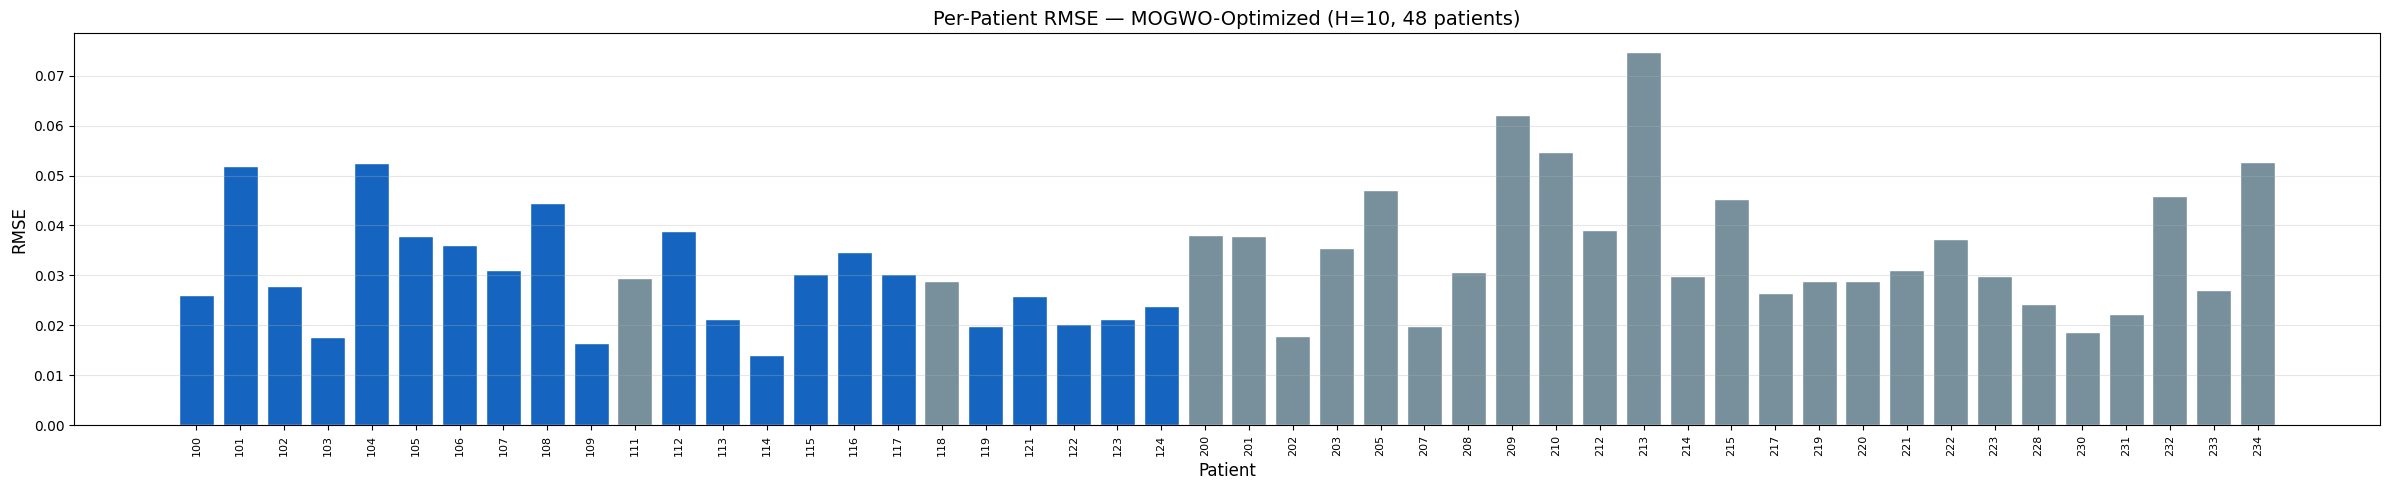

In [12]:
# ── 7.1 Per-Patient RMSE Bar — ALL patients ─────────────────────────────────
df_sorted = df_results.sort_values('Patient').reset_index(drop=True)
fig, ax = plt.subplots(figsize=(max(16, len(PATIENTS) * 0.5), 5))
x = np.arange(len(PATIENTS))

# Color bars: blue if also in GWO, grey if new
colors = ['#1565C0' if p in GWO_PATIENT_IDS else '#78909C' for p in df_sorted.Patient]
ax.bar(x, df_sorted.RMSE.values, color=colors, edgecolor='white')

ax.set_xlabel('Patient', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title(f'Per-Patient RMSE — MOGWO-Optimized (H={HORIZON}, {len(PATIENTS)} patients)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(df_sorted.Patient.values, rotation=90, fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/per_patient_rmse_all.png', dpi=200, bbox_inches='tight')
plt.show()

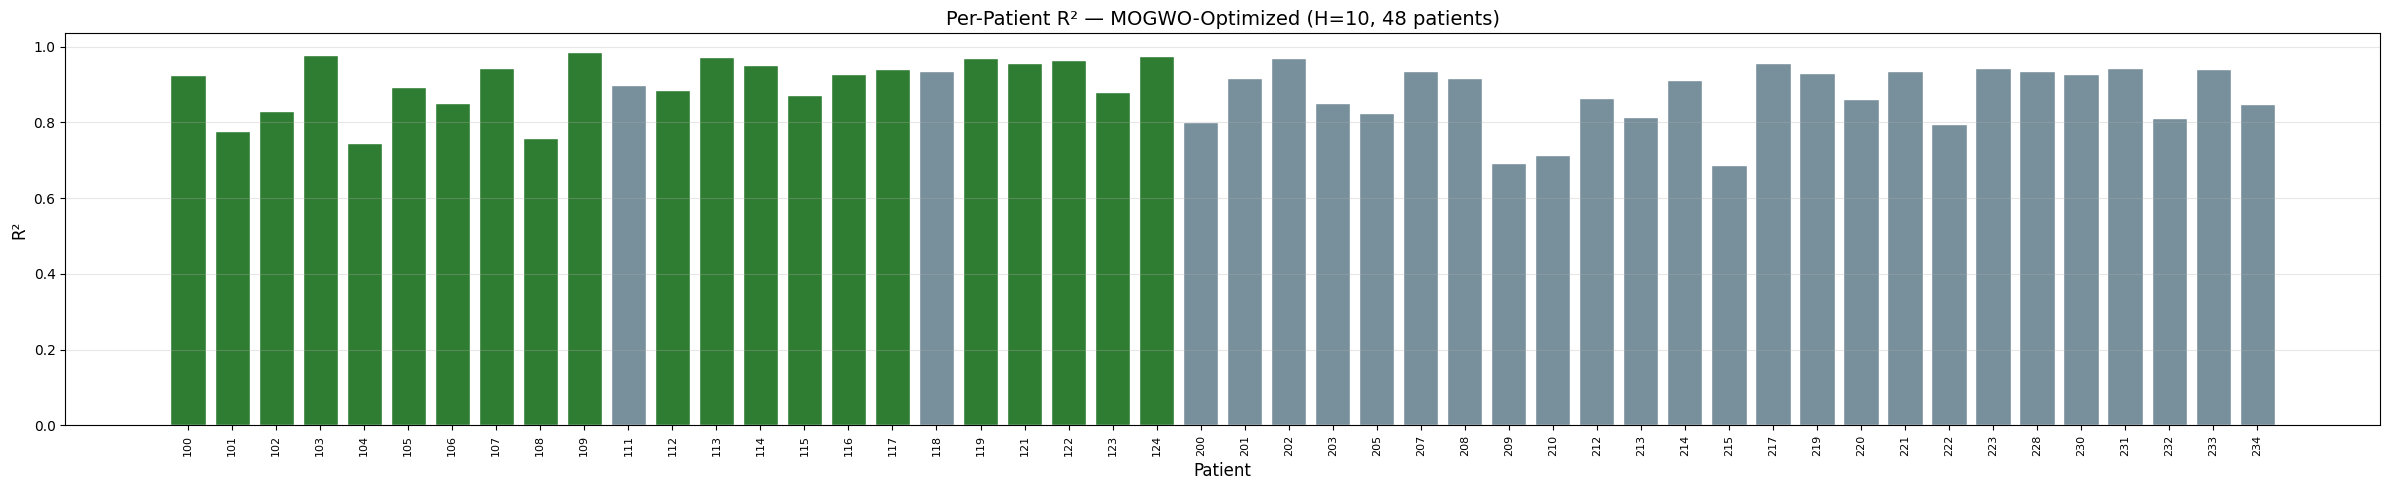

In [13]:
# ── 7.2 Per-Patient R² Bar — ALL patients ────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(16, len(PATIENTS) * 0.5), 5))
colors_r2 = ['#2E7D32' if p in GWO_PATIENT_IDS else '#78909C' for p in df_sorted.Patient]
ax.bar(x, df_sorted.R2.values, color=colors_r2, edgecolor='white')

ax.set_xlabel('Patient', fontsize=12)
ax.set_ylabel('R²', fontsize=12)
ax.set_title(f'Per-Patient R² — MOGWO-Optimized (H={HORIZON}, {len(PATIENTS)} patients)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(df_sorted.Patient.values, rotation=90, fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/per_patient_r2_all.png', dpi=200, bbox_inches='tight')
plt.show()

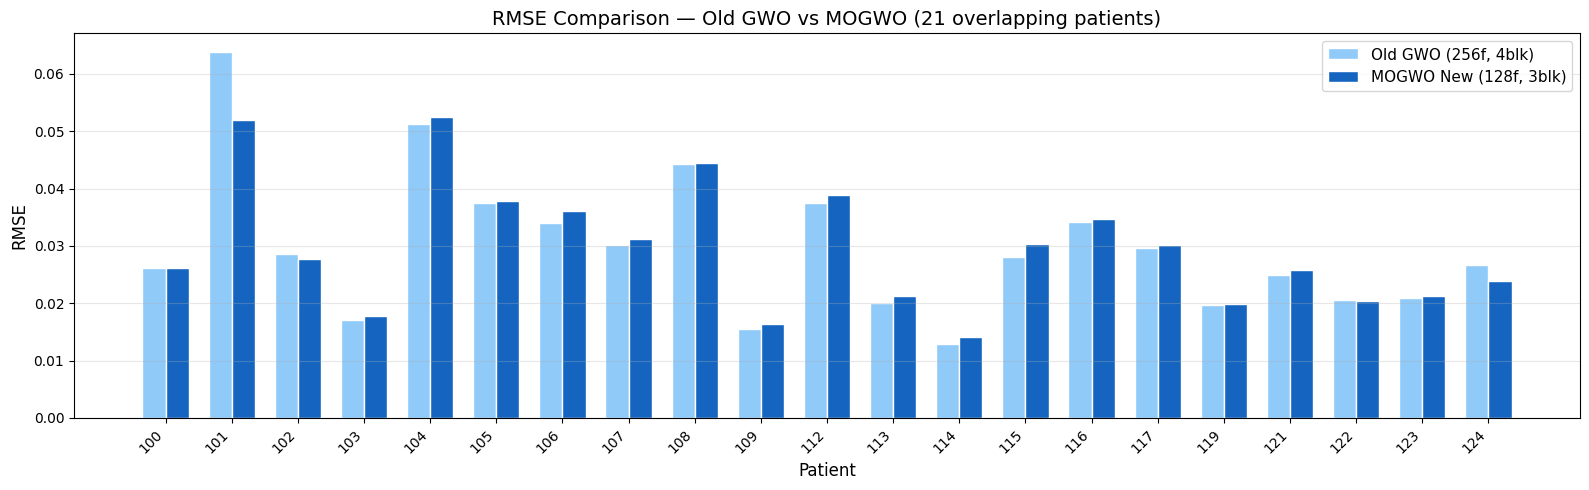

In [14]:
# ── 7.3 Comparison bars (overlapping 21 patients only) ────────────────────────
if len(overlap_patients) > 0:
    fig, ax = plt.subplots(figsize=(16, 5))
    xo = np.arange(len(overlap_patients))
    w = 0.35

    ax.bar(xo - w/2, df_gwo_overlap.RMSE.values, w,
           label='Old GWO (256f, 4blk)', color='#90CAF9', edgecolor='white')
    ax.bar(xo + w/2, df_mogwo_overlap.RMSE.values, w,
           label='MOGWO New (128f, 3blk)', color='#1565C0', edgecolor='white')

    ax.set_xlabel('Patient', fontsize=12)
    ax.set_ylabel('RMSE', fontsize=12)
    ax.set_title(f'RMSE Comparison — Old GWO vs MOGWO ({len(overlap_patients)} overlapping patients)', fontsize=14)
    ax.set_xticks(xo)
    ax.set_xticklabels(overlap_patients, rotation=45, ha='right')
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/rmse_comparison_overlap.png', dpi=200, bbox_inches='tight')
    plt.show()

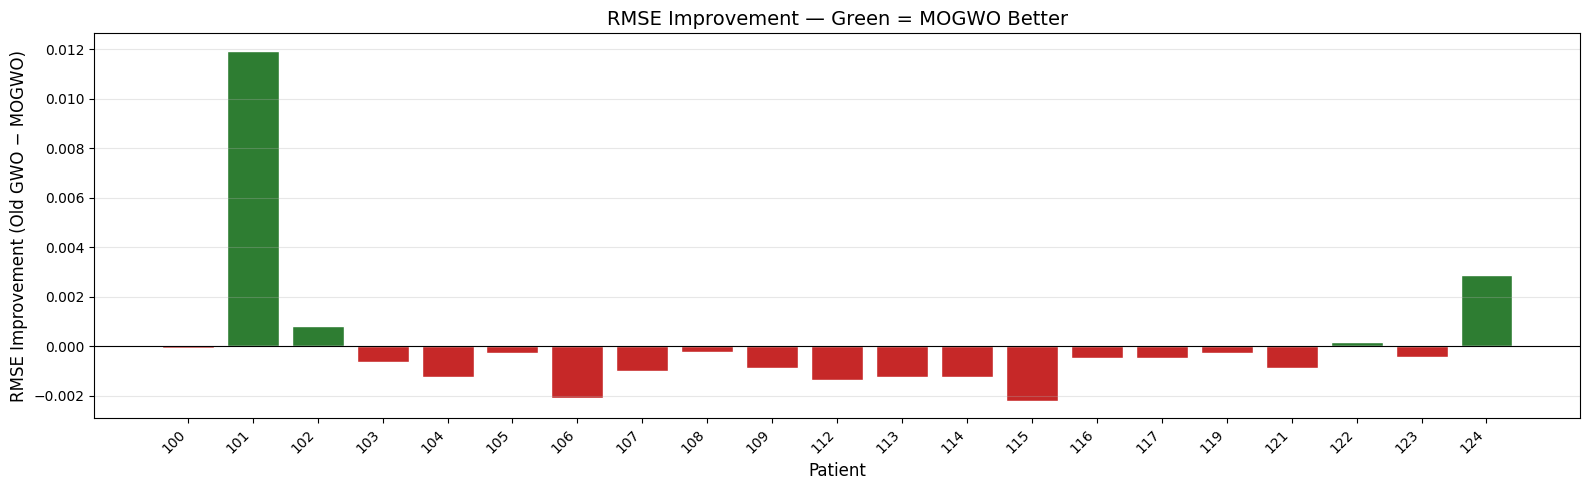

In [15]:
# ── 7.4 RMSE Improvement Waterfall (overlapping patients) ─────────────────────
if len(overlap_patients) > 0:
    improvement = df_gwo_overlap.RMSE.values - df_mogwo_overlap.RMSE.values
    colors_wf = ['#2E7D32' if imp > 0 else '#C62828' for imp in improvement]

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.bar(xo, improvement, color=colors_wf, edgecolor='white')
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_xlabel('Patient', fontsize=12)
    ax.set_ylabel('RMSE Improvement (Old GWO − MOGWO)', fontsize=12)
    ax.set_title('RMSE Improvement — Green = MOGWO Better', fontsize=14)
    ax.set_xticks(xo)
    ax.set_xticklabels(overlap_patients, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/rmse_improvement_waterfall.png', dpi=200, bbox_inches='tight')
    plt.show()

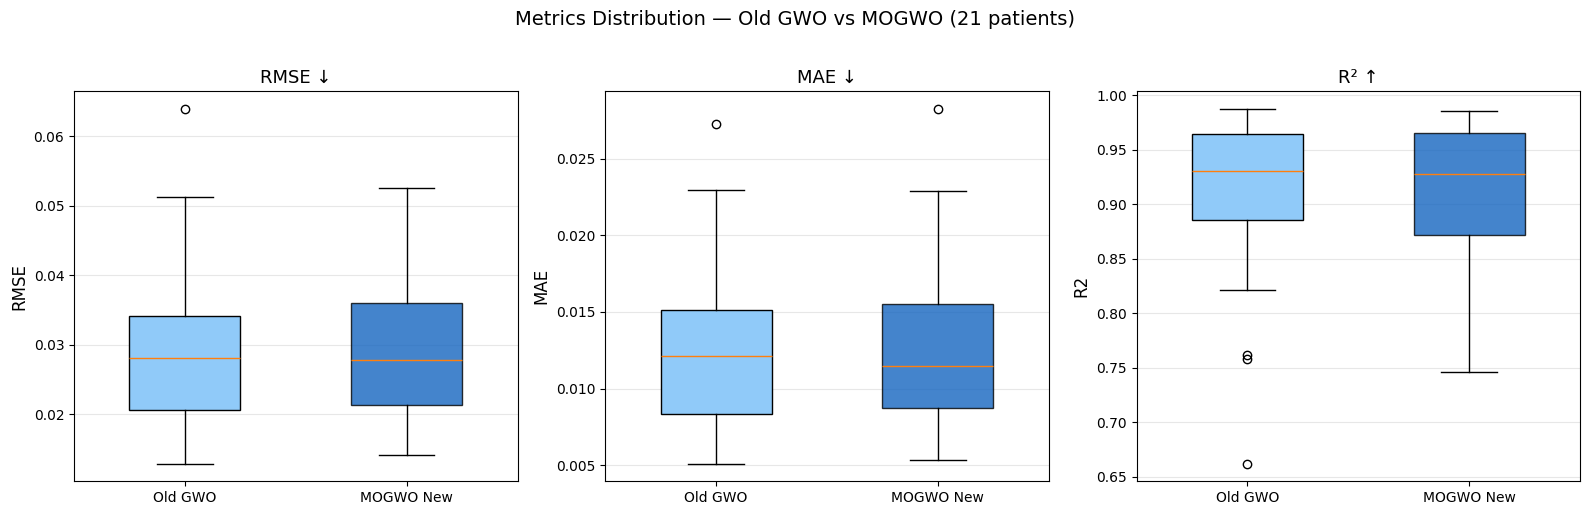

In [16]:
# ── 7.5 Metrics Box Plots (overlapping patients) ─────────────────────────────
if len(overlap_patients) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, metric, title in zip(axes,
        ['RMSE', 'MAE', 'R2'], ['RMSE ↓', 'MAE ↓', 'R² ↑']):
        data = [df_gwo_overlap[metric].values, df_mogwo_overlap[metric].values]
        bp = ax.boxplot(data, labels=['Old GWO', 'MOGWO New'], patch_artist=True, widths=0.5)
        bp['boxes'][0].set_facecolor('#90CAF9')
        bp['boxes'][1].set_facecolor('#1565C0')
        bp['boxes'][1].set(alpha=0.8)
        ax.set_ylabel(metric, fontsize=12)
        ax.set_title(title, fontsize=13)
        ax.grid(axis='y', alpha=0.3)
    plt.suptitle(f'Metrics Distribution — Old GWO vs MOGWO ({len(overlap_patients)} patients)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/metrics_boxplots.png', dpi=200, bbox_inches='tight')
    plt.show()

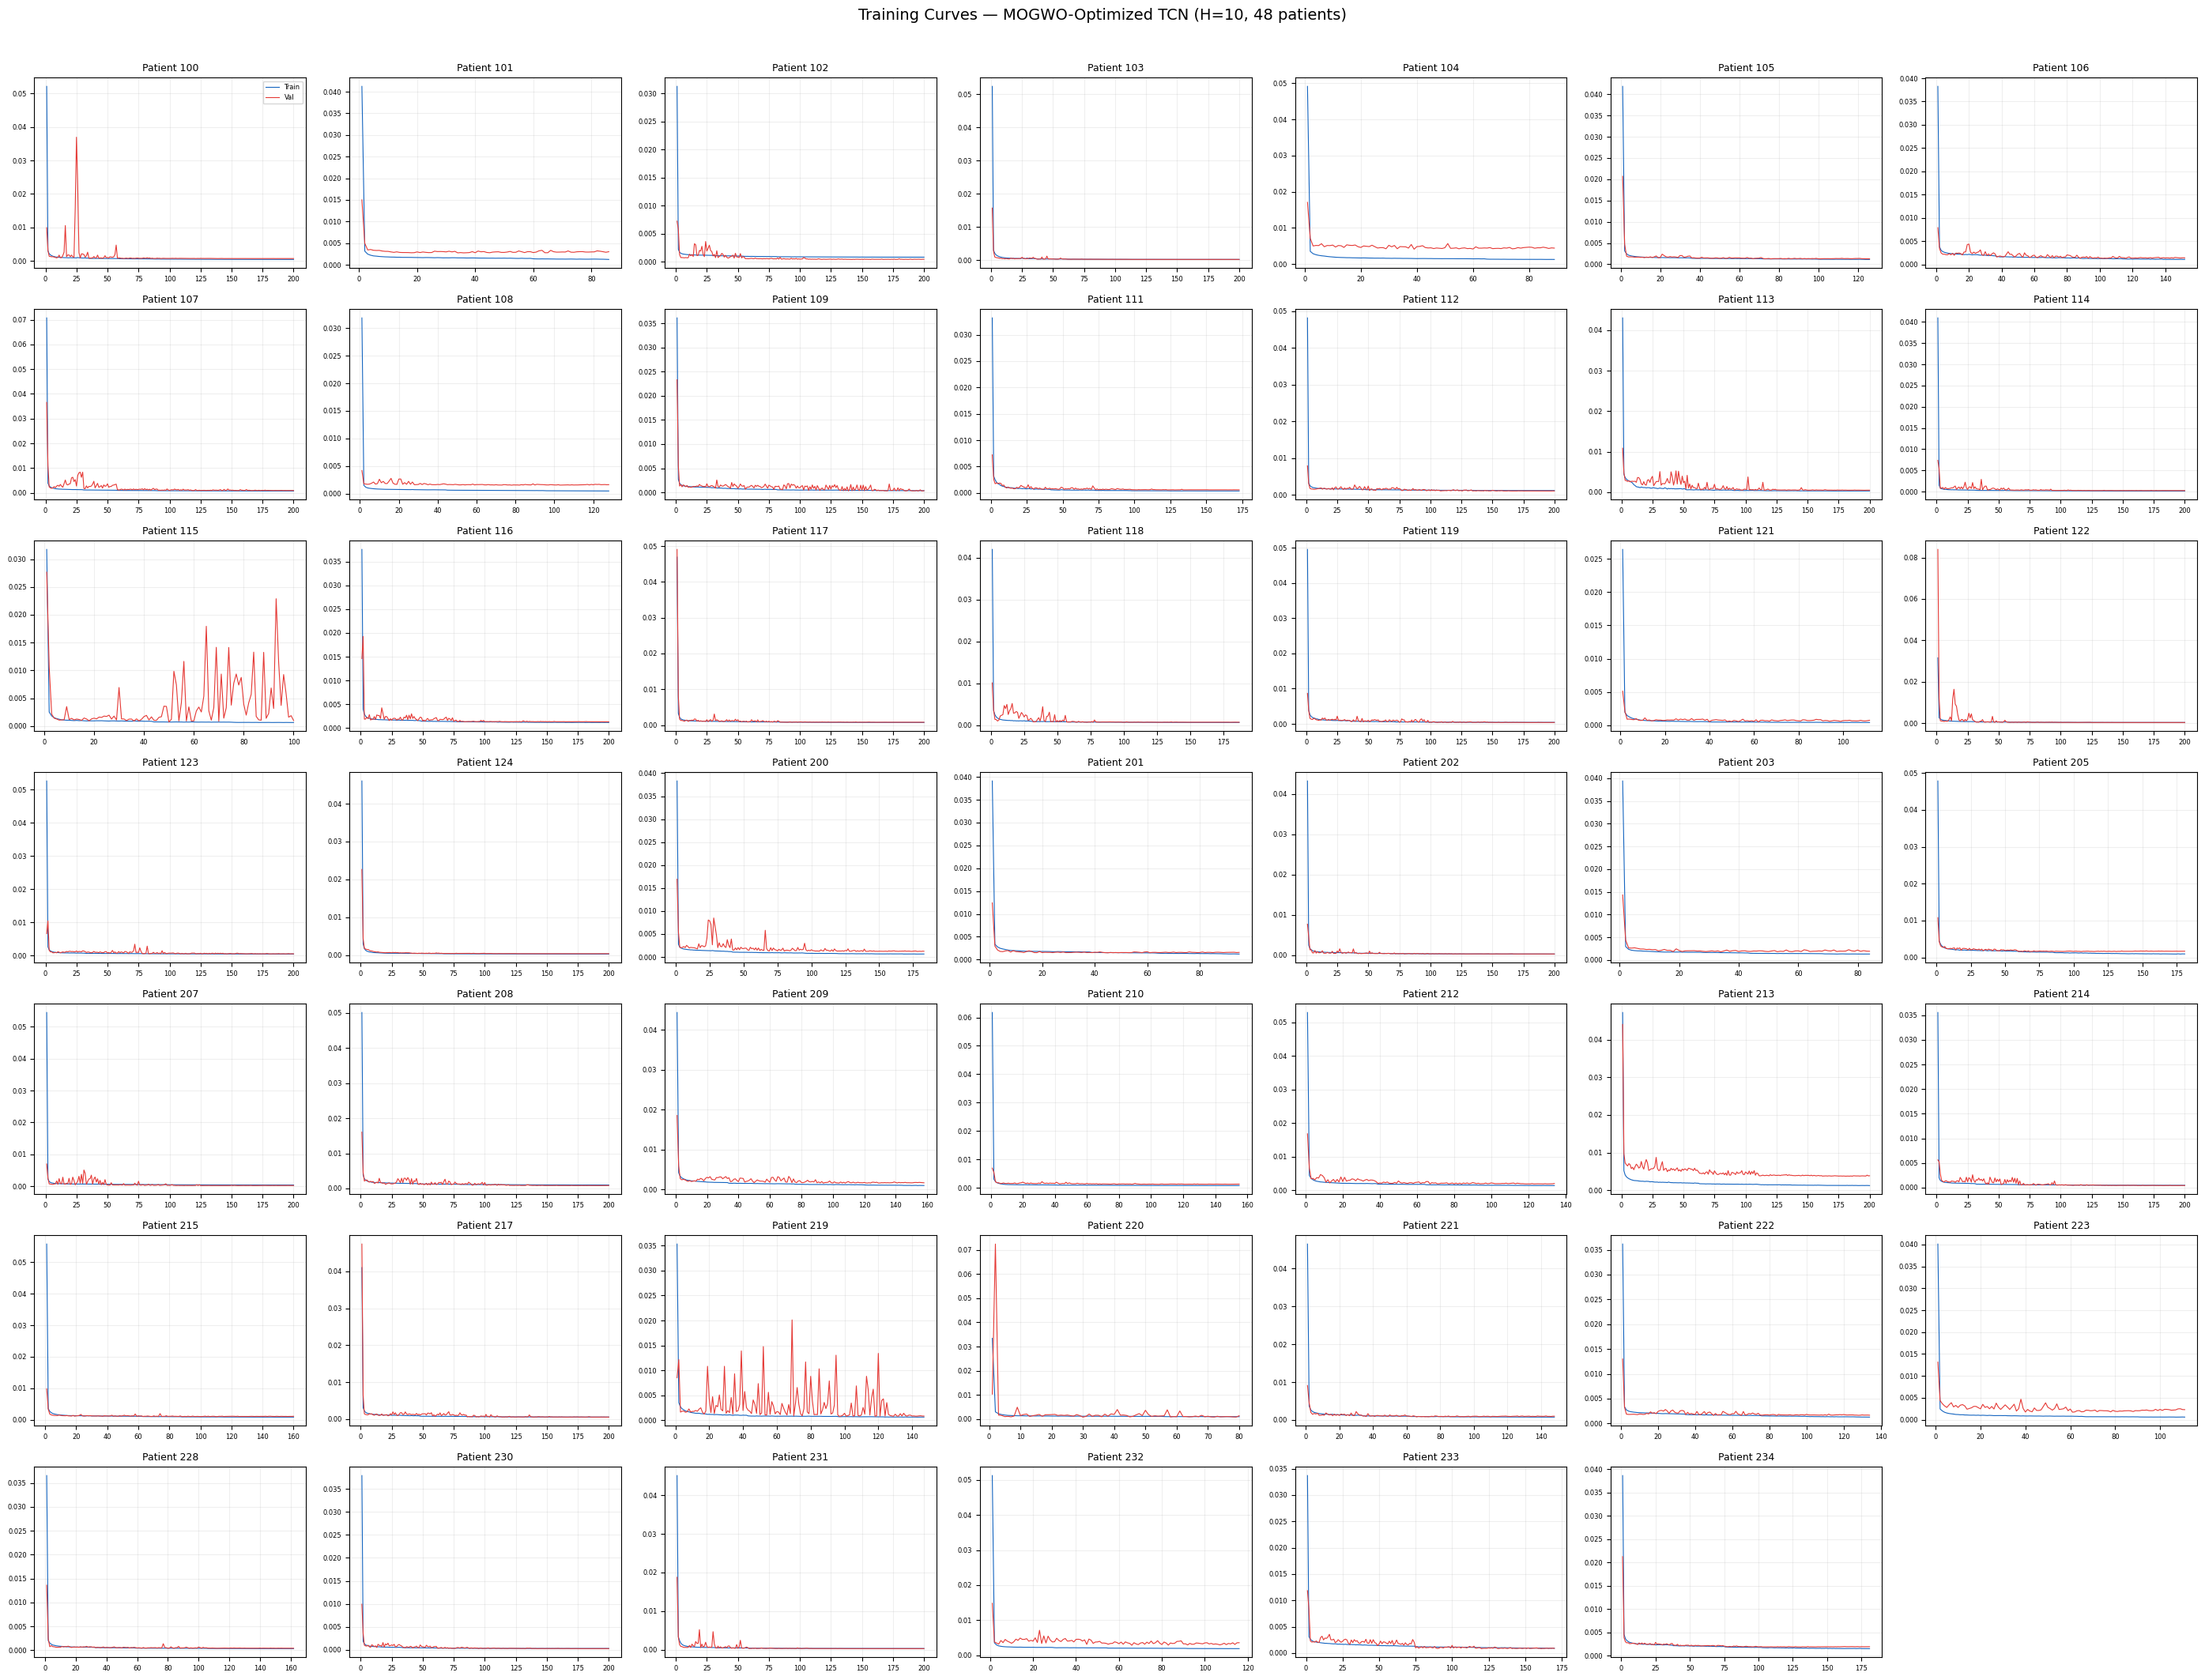

In [17]:
# ── 7.6 Training Curves (all patients) ───────────────────────────────────────
n_patients = len(PATIENTS)
nc = 7
nr = int(np.ceil(n_patients / nc))
fig, axes = plt.subplots(nr, nc, figsize=(4 * nc, 3 * nr), sharey=False)
axes_flat = axes.flatten()

for idx, rid in enumerate(PATIENTS):
    ax = axes_flat[idx]
    hist = training_histories[rid]
    epochs_range = range(1, len(hist['loss']) + 1)
    ax.plot(epochs_range, hist['loss'], label='Train', linewidth=0.8, color='#1565C0')
    ax.plot(epochs_range, hist['val_loss'], label='Val', linewidth=0.8, color='#E53935')
    ax.set_title(f'Patient {rid}', fontsize=9)
    ax.tick_params(labelsize=6)
    ax.grid(alpha=0.2)
    if idx == 0:
        ax.legend(fontsize=6)

# Hide unused subplots
for idx in range(n_patients, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle(f'Training Curves — MOGWO-Optimized TCN (H={HORIZON}, {n_patients} patients)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/training_curves_all.png', dpi=200, bbox_inches='tight')
plt.show()

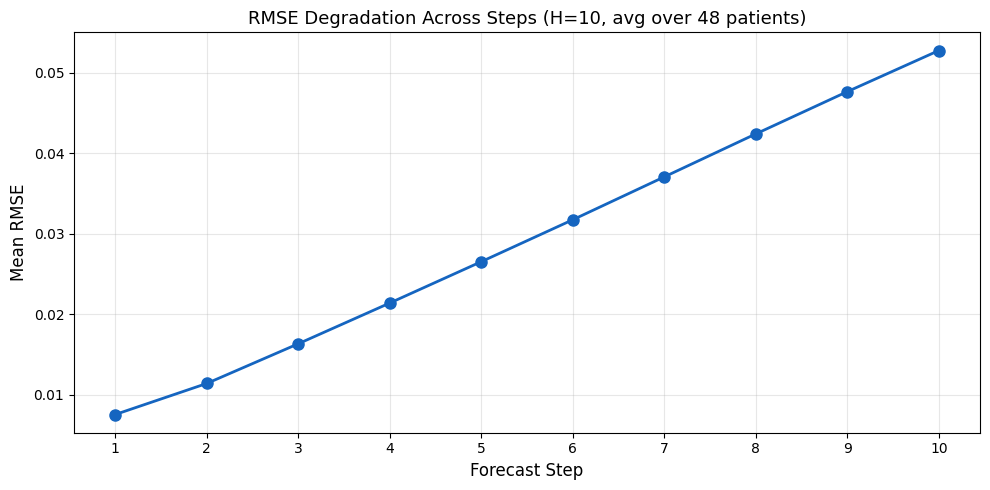

In [18]:
# ── 7.7 Per-Step RMSE Degradation ────────────────────────────────────────────
all_step_rmse = np.zeros(HORIZON)
for rid in PATIENTS:
    all_step_rmse += per_step_results[rid].RMSE.values
all_step_rmse /= len(PATIENTS)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, HORIZON + 1), all_step_rmse, 'o-', color='#1565C0',
        linewidth=2, markersize=8)
ax.set_xlabel('Forecast Step', fontsize=12)
ax.set_ylabel('Mean RMSE', fontsize=12)
ax.set_title(f'RMSE Degradation Across Steps (H={HORIZON}, avg over {len(PATIENTS)} patients)', fontsize=13)
ax.set_xticks(range(1, HORIZON + 1))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/per_step_rmse_degradation.png', dpi=200, bbox_inches='tight')
plt.show()

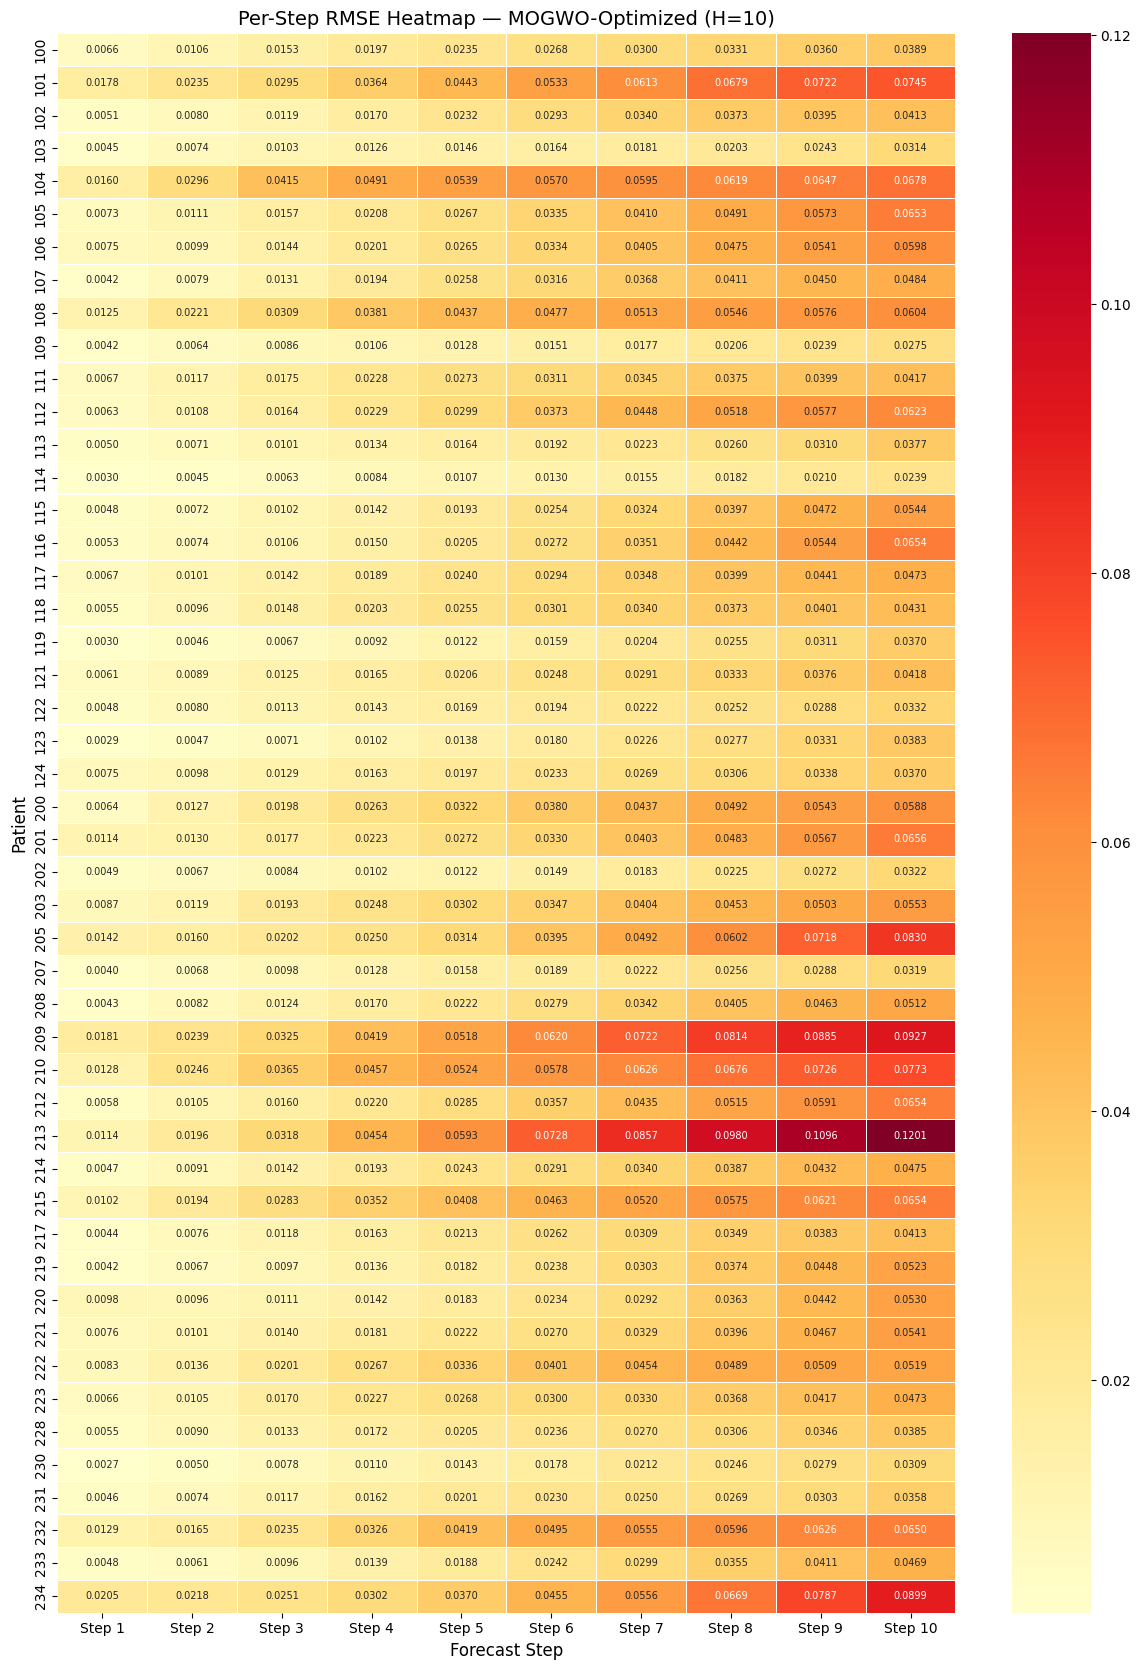

In [19]:
# ── 7.8 Per-Step RMSE Heatmap (all patients) ─────────────────────────────────
step_rmse_matrix = np.zeros((len(PATIENTS), HORIZON))
for i, rid in enumerate(PATIENTS):
    step_rmse_matrix[i, :] = per_step_results[rid].RMSE.values

fig, ax = plt.subplots(figsize=(12, max(8, len(PATIENTS) * 0.35)))
sns.heatmap(step_rmse_matrix, annot=True, fmt='.4f', cmap='YlOrRd',
            xticklabels=[f'Step {i+1}' for i in range(HORIZON)],
            yticklabels=PATIENTS, ax=ax, linewidths=0.5,
            annot_kws={'fontsize': 7})
ax.set_xlabel('Forecast Step', fontsize=12)
ax.set_ylabel('Patient', fontsize=12)
ax.set_title(f'Per-Step RMSE Heatmap — MOGWO-Optimized (H={HORIZON})', fontsize=14)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/per_step_rmse_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

## 8 — Signal Visualization (10 Random Patients)

Actual vs Predicted ECG signal for **10 randomly selected patients** at:
- **Step 1** (1-step-ahead, easiest)
- **Step 10** (10-step-ahead, hardest — full horizon)

In [20]:
print(f'Signal visualization patients ({len(VIZ_PATIENTS)}): {VIZ_PATIENTS}')

Signal visualization patients (10): ['104', '113', '121', '201', '202', '203', '205', '219', '222', '230']


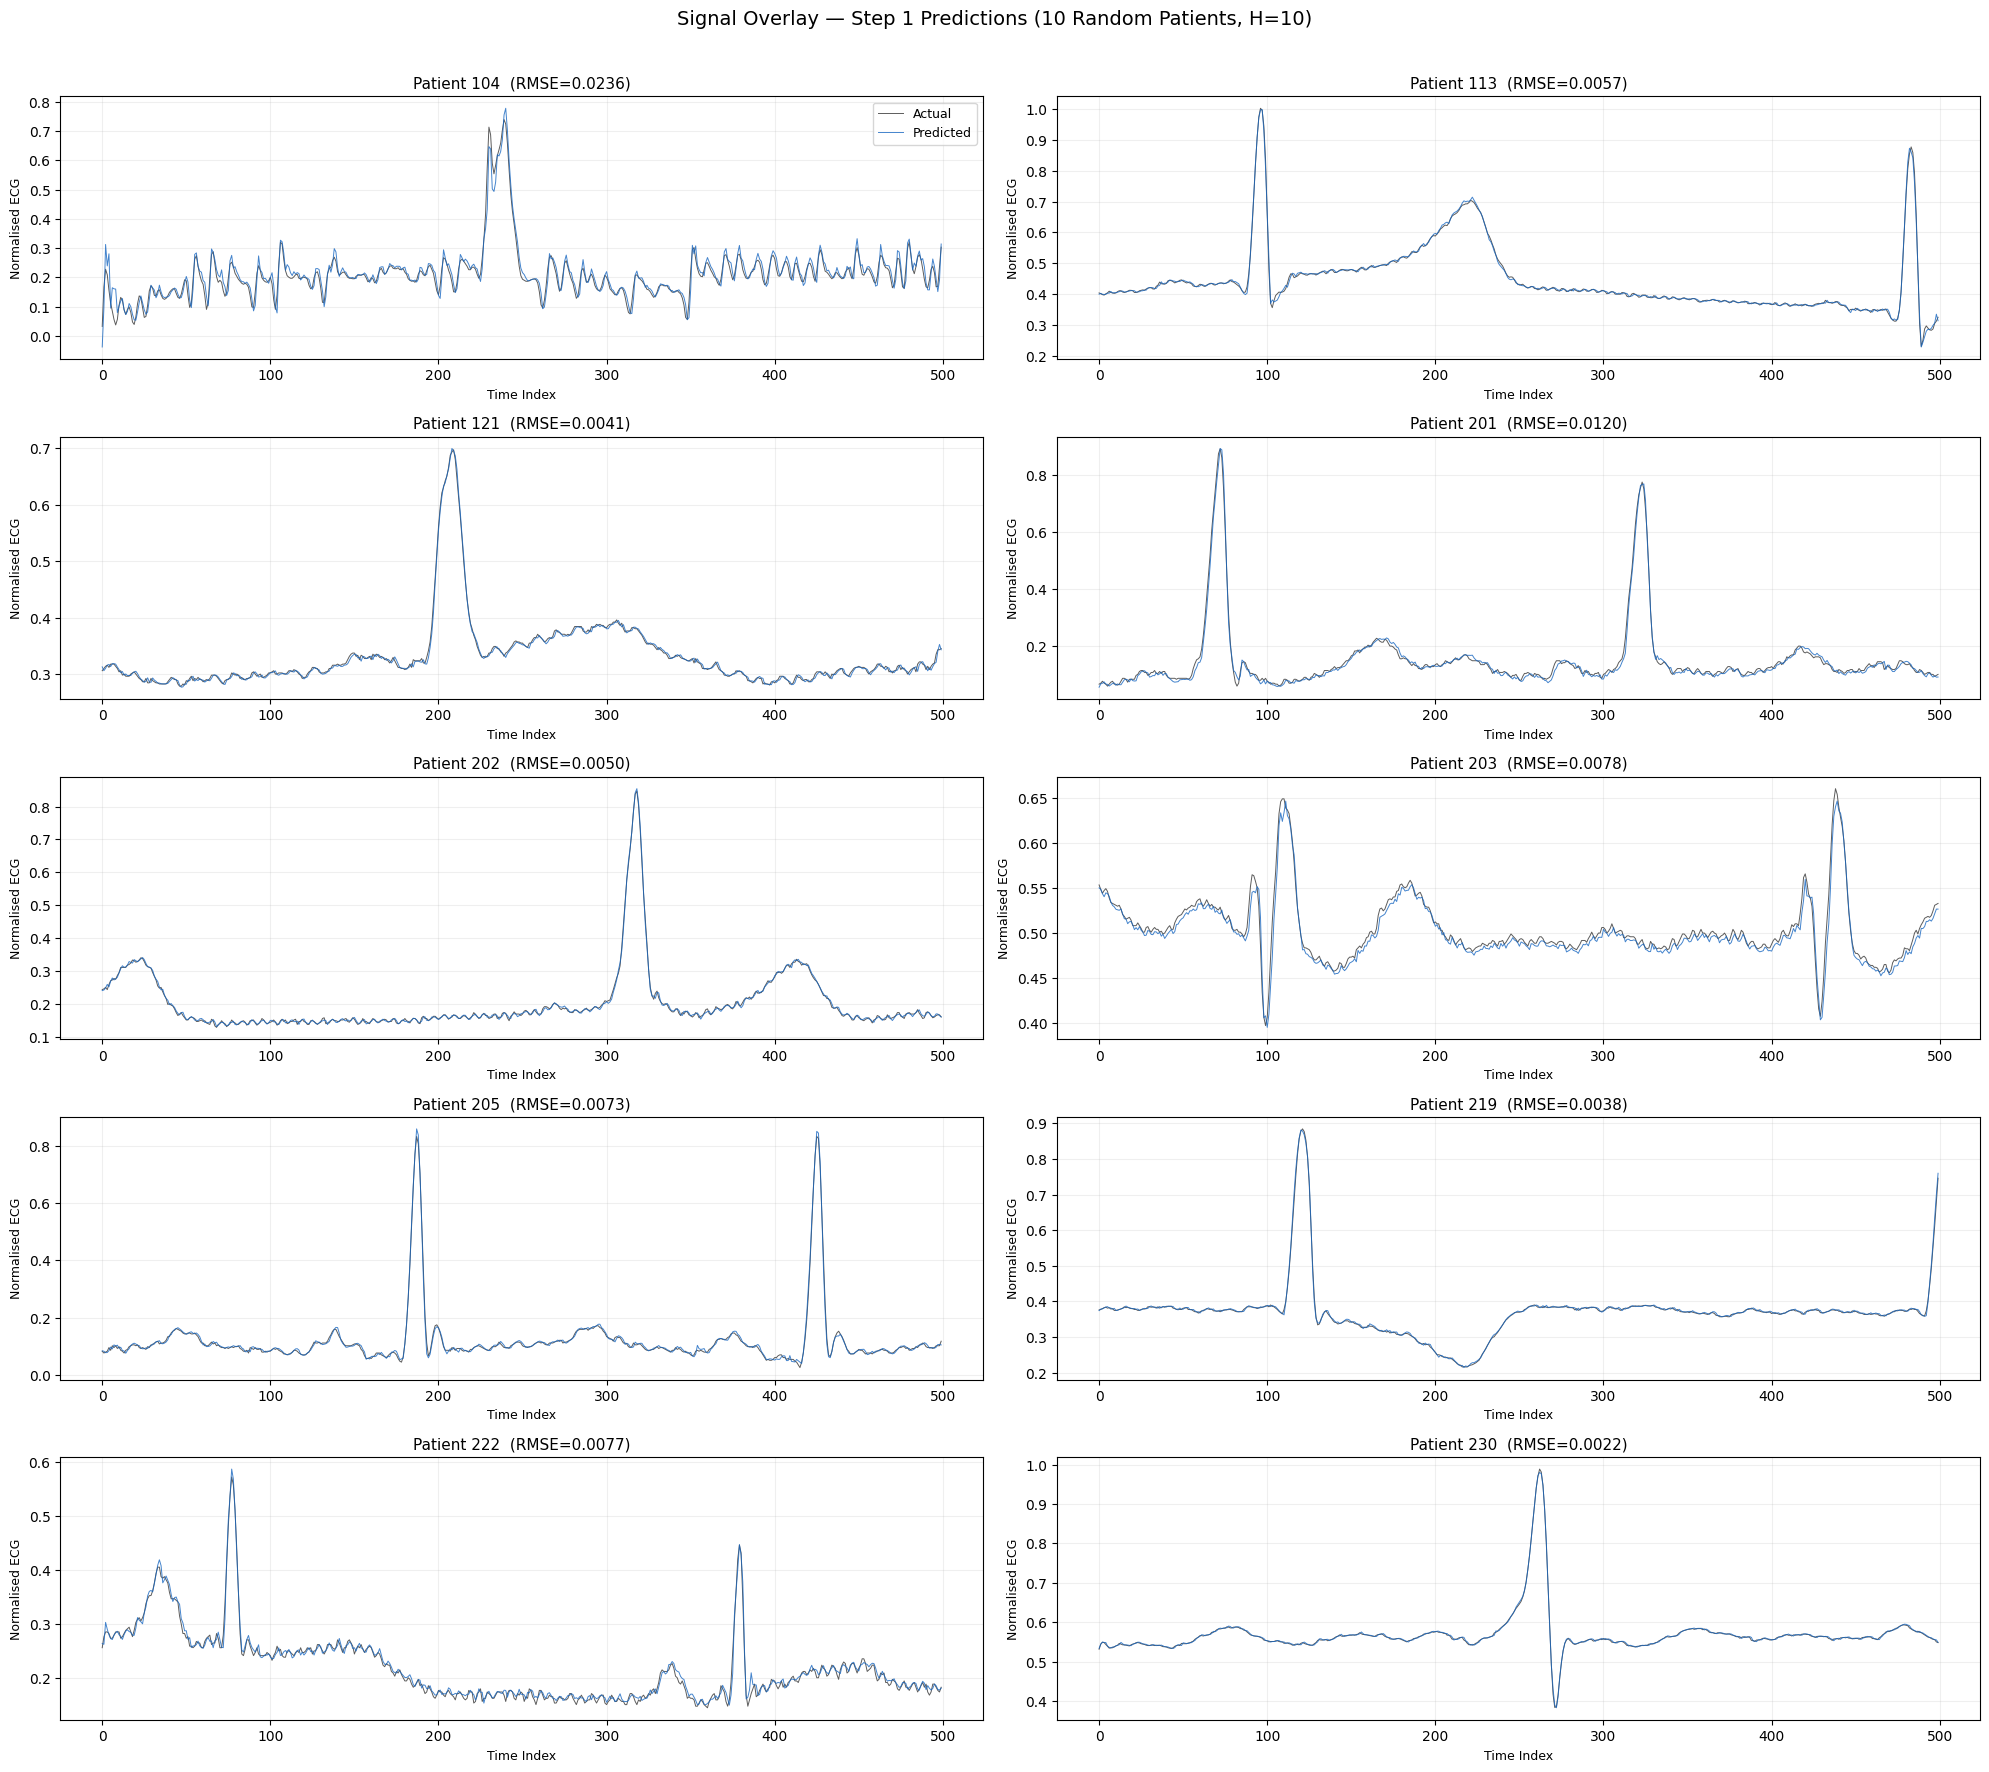

In [21]:
# ── 8.1 Signal Overlay — Step 1 (10 Random Patients) ─────────────────────────
N_SHOW = 500
n_viz = len(VIZ_PATIENTS)
nc_viz = 2
nr_viz = int(np.ceil(n_viz / nc_viz))
fig, axes = plt.subplots(nr_viz, nc_viz, figsize=(20, 3.5 * nr_viz))
axes_flat = axes.flatten()

for idx, rid in enumerate(VIZ_PATIENTS):
    ax = axes_flat[idx]
    y_true, y_pred = saved_preds[rid]
    actual    = y_true[:N_SHOW, 0]
    predicted = y_pred[:N_SHOW, 0]
    rmse_p = float(np.sqrt(mean_squared_error(actual, predicted)))

    ax.plot(actual, color='#333333', linewidth=0.7, alpha=0.8, label='Actual')
    ax.plot(predicted, color='#1565C0', linewidth=0.7, alpha=0.8, label='Predicted')
    ax.set_title(f'Patient {rid}  (RMSE={rmse_p:.4f})', fontsize=11)
    ax.set_xlabel('Time Index', fontsize=9)
    ax.set_ylabel('Normalised ECG', fontsize=9)
    ax.grid(alpha=0.2)
    if idx == 0:
        ax.legend(fontsize=9, loc='upper right')

for idx in range(n_viz, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle(f'Signal Overlay — Step 1 Predictions (10 Random Patients, H={HORIZON})',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/signal_overlay_step1.png', dpi=200, bbox_inches='tight')
plt.show()

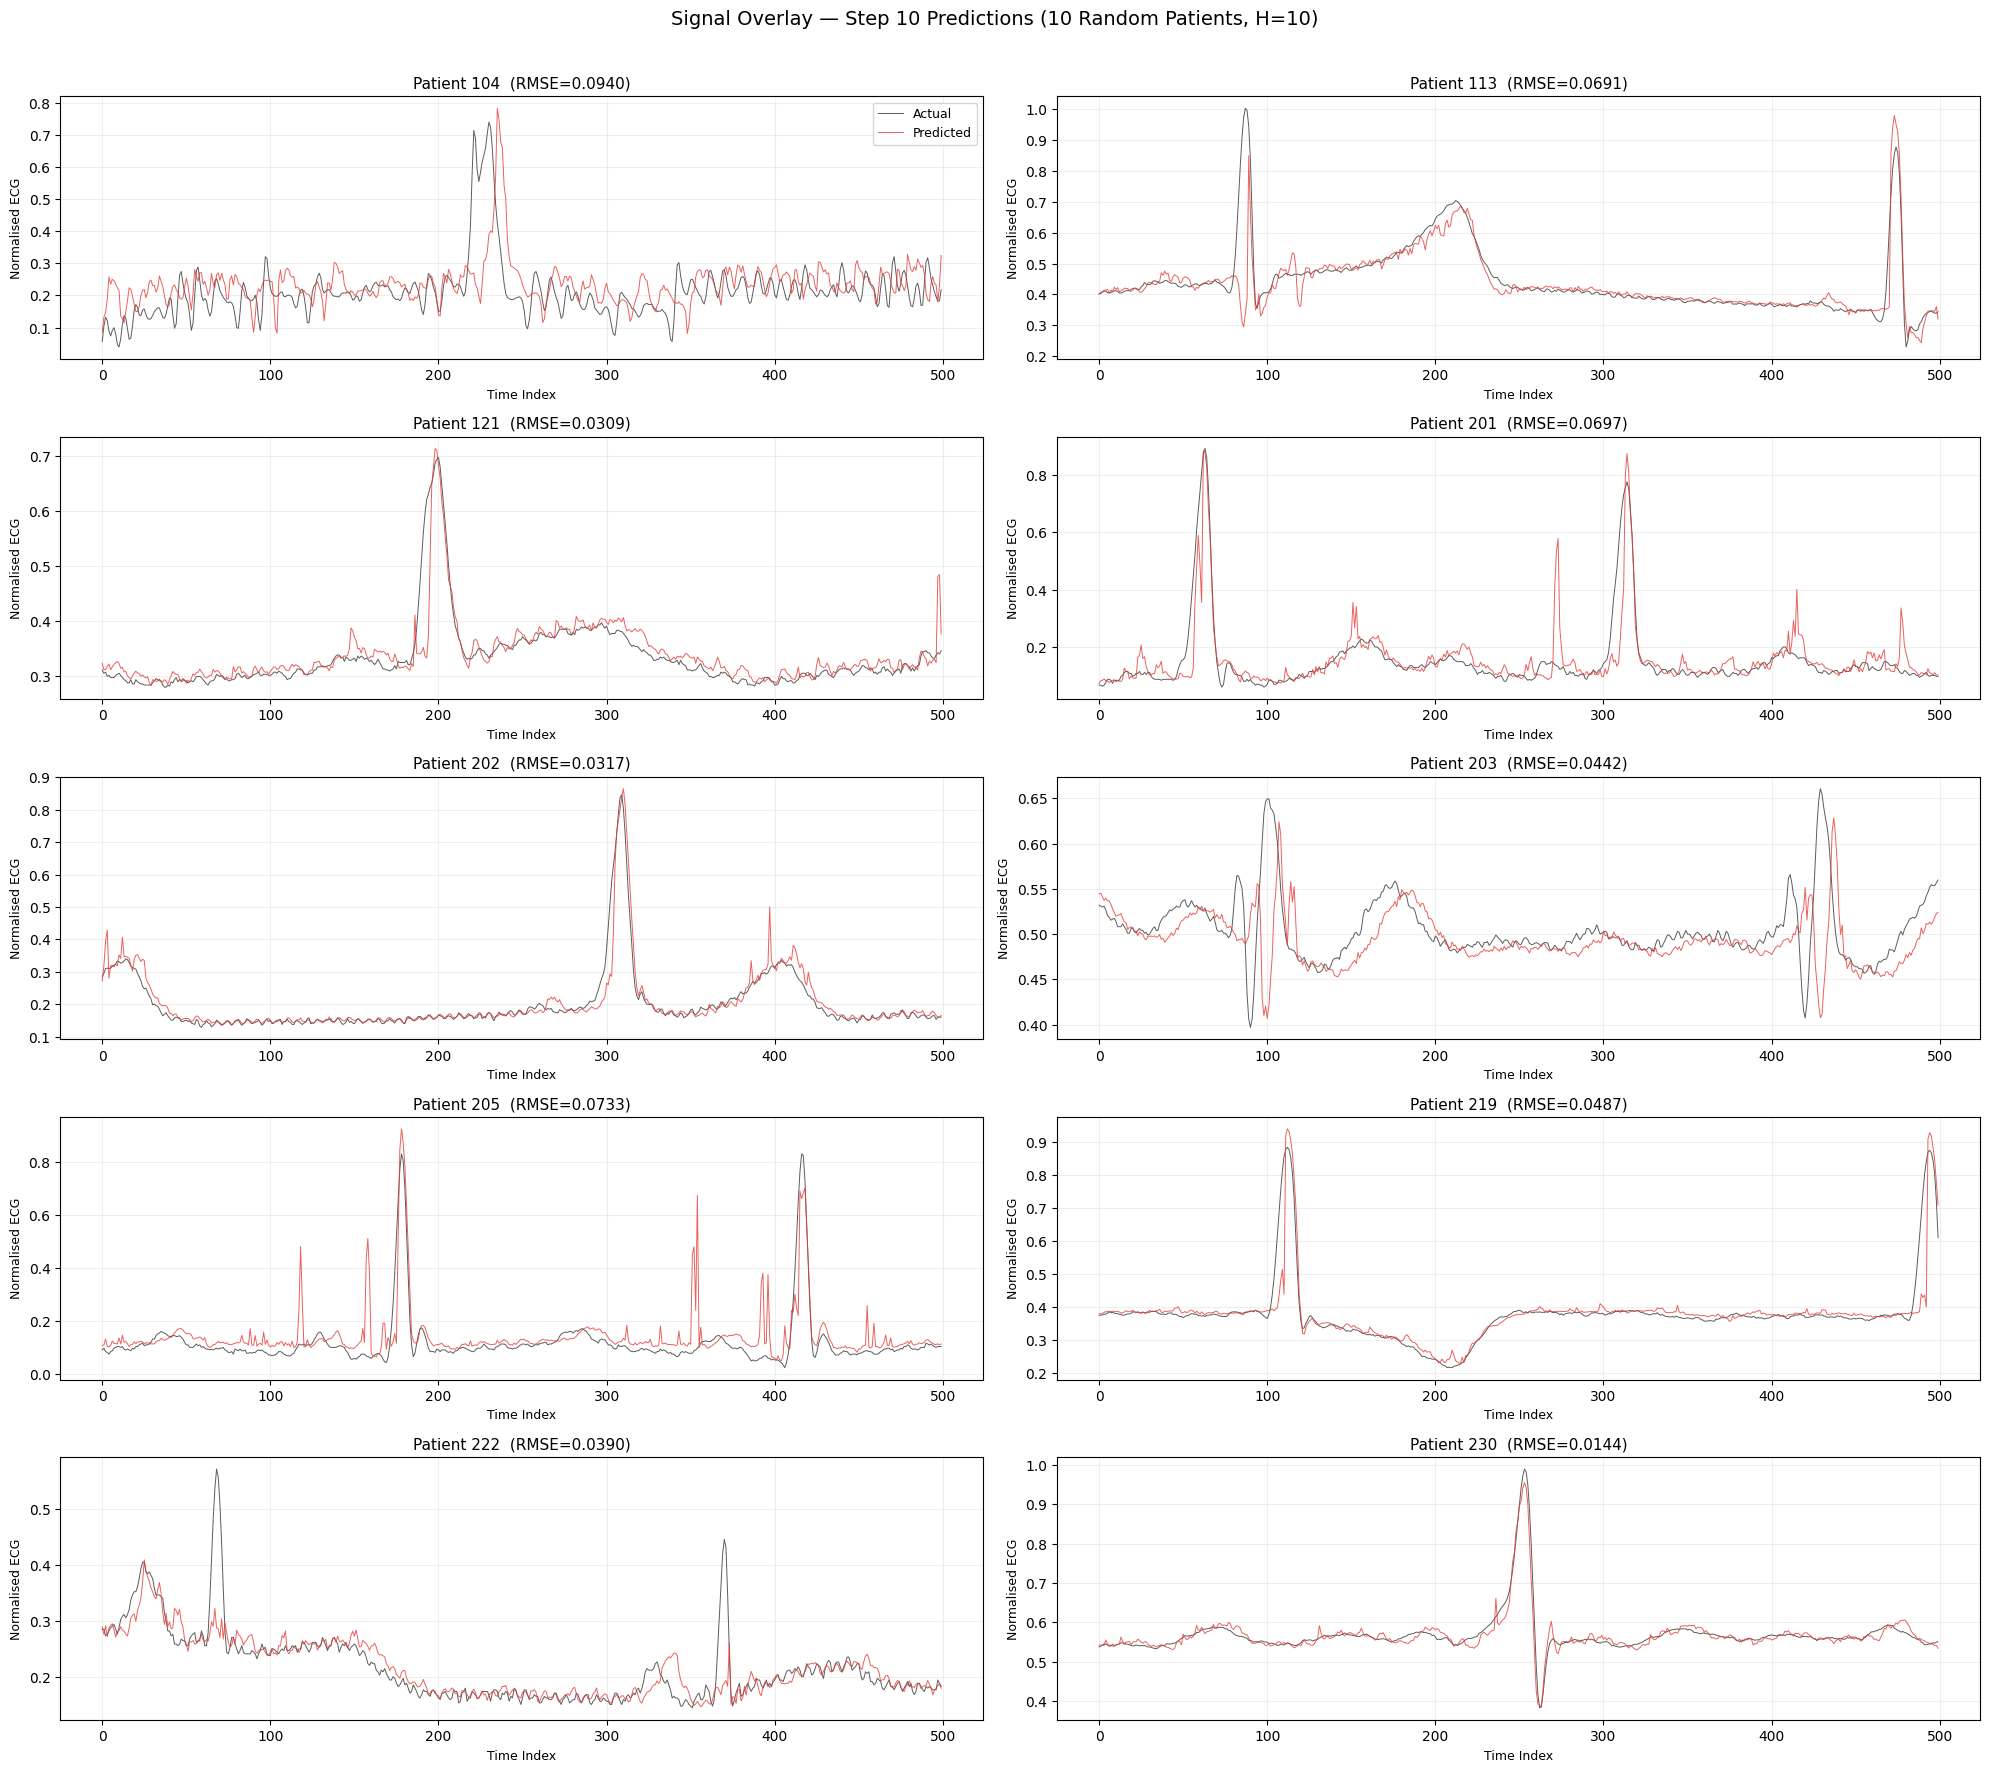

In [22]:
# ── 8.2 Signal Overlay — Step 10 (10 Random Patients) ────────────────────────
fig, axes = plt.subplots(nr_viz, nc_viz, figsize=(20, 3.5 * nr_viz))
axes_flat = axes.flatten()

for idx, rid in enumerate(VIZ_PATIENTS):
    ax = axes_flat[idx]
    y_true, y_pred = saved_preds[rid]
    actual    = y_true[:N_SHOW, HORIZON - 1]
    predicted = y_pred[:N_SHOW, HORIZON - 1]
    rmse_p = float(np.sqrt(mean_squared_error(actual, predicted)))

    ax.plot(actual, color='#333333', linewidth=0.7, alpha=0.8, label='Actual')
    ax.plot(predicted, color='#E53935', linewidth=0.7, alpha=0.8, label='Predicted')
    ax.set_title(f'Patient {rid}  (RMSE={rmse_p:.4f})', fontsize=11)
    ax.set_xlabel('Time Index', fontsize=9)
    ax.set_ylabel('Normalised ECG', fontsize=9)
    ax.grid(alpha=0.2)
    if idx == 0:
        ax.legend(fontsize=9, loc='upper right')

for idx in range(n_viz, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle(f'Signal Overlay — Step 10 Predictions (10 Random Patients, H={HORIZON})',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/signal_overlay_step10.png', dpi=200, bbox_inches='tight')
plt.show()

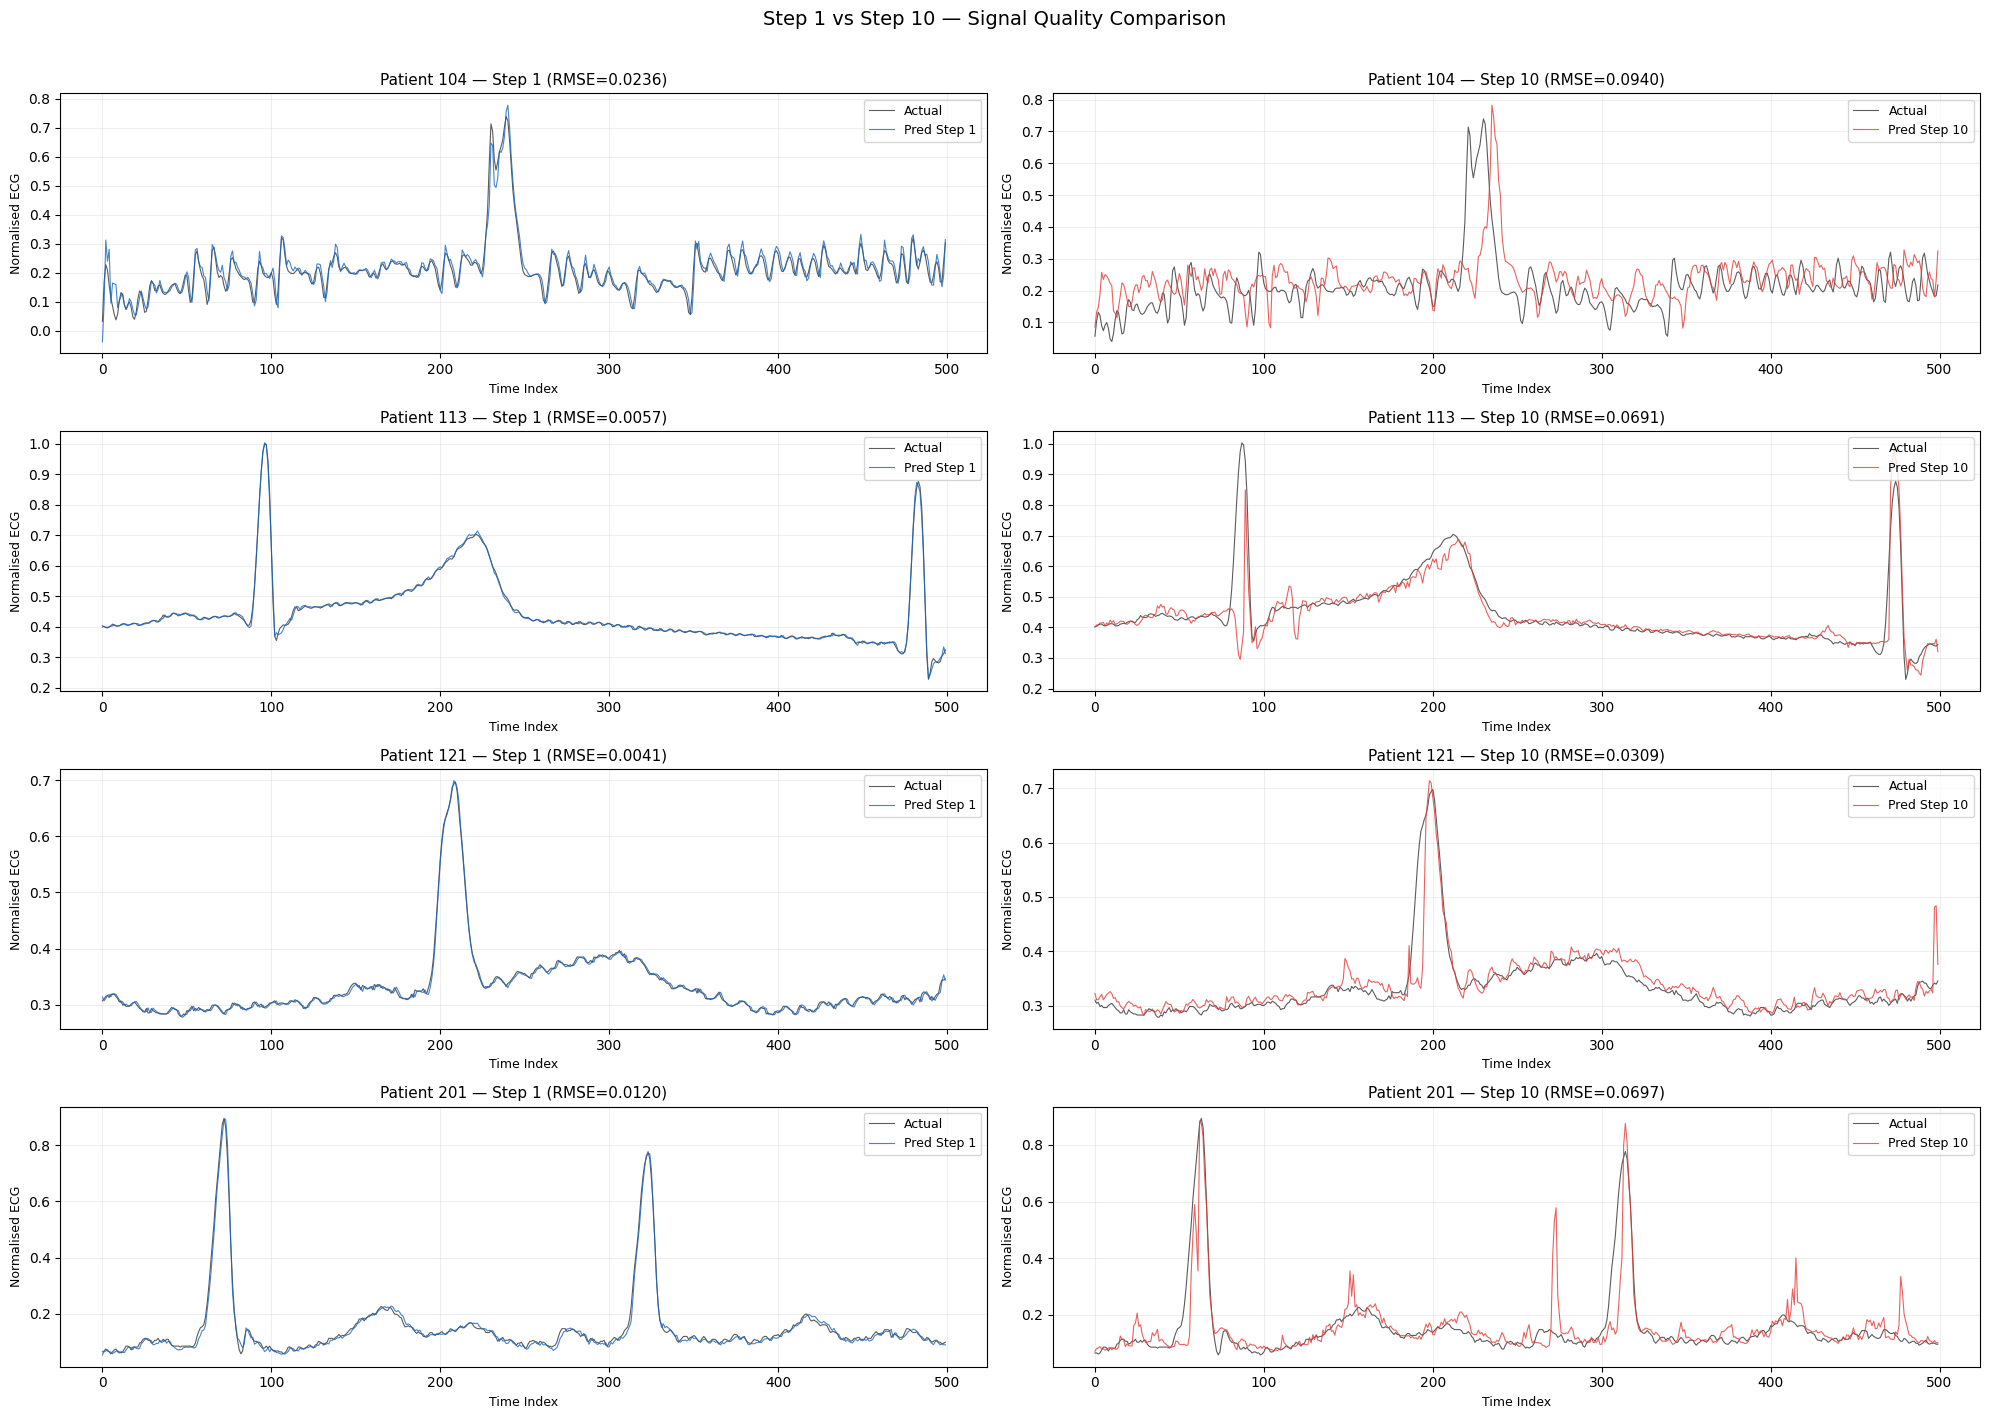

In [23]:
# ── 8.3 Step 1 vs Step 10 Side-by-Side (4 from viz sample) ───────────────────
sample_4 = VIZ_PATIENTS[:4]

fig, axes = plt.subplots(len(sample_4), 2, figsize=(20, 14))

for row_idx, rid in enumerate(sample_4):
    y_true, y_pred = saved_preds[rid]
    for col_idx, (step_idx, step_label, color) in enumerate([
        (0, 'Step 1', '#1565C0'),
        (HORIZON - 1, f'Step {HORIZON}', '#E53935'),
    ]):
        ax = axes[row_idx, col_idx]
        actual    = y_true[:N_SHOW, step_idx]
        predicted = y_pred[:N_SHOW, step_idx]
        rmse_p = float(np.sqrt(mean_squared_error(actual, predicted)))

        ax.plot(actual, color='#333333', linewidth=0.8, alpha=0.8, label='Actual')
        ax.plot(predicted, color=color, linewidth=0.8, alpha=0.8, label=f'Pred {step_label}')
        ax.set_title(f'Patient {rid} — {step_label} (RMSE={rmse_p:.4f})', fontsize=11)
        ax.set_xlabel('Time Index', fontsize=9)
        ax.set_ylabel('Normalised ECG', fontsize=9)
        ax.legend(fontsize=9, loc='upper right')
        ax.grid(alpha=0.2)

plt.suptitle(f'Step 1 vs Step {HORIZON} — Signal Quality Comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/signal_step1_vs_step10.png', dpi=200, bbox_inches='tight')
plt.show()

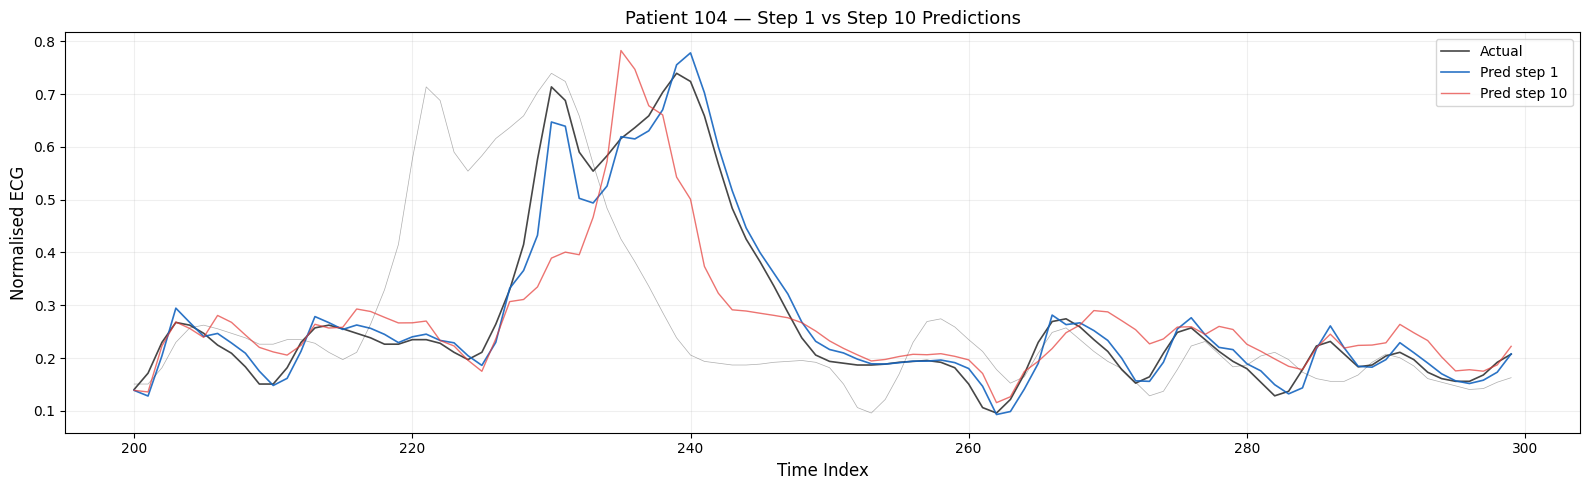

In [24]:
# ── 8.4 Multi-Step Prediction Fan (first viz patient) ─────────────────────────
rid = VIZ_PATIENTS[0]
y_true, y_pred = saved_preds[rid]
start = 200
window = 100

fig, ax = plt.subplots(figsize=(16, 5))
for step in range(HORIZON):
    if step == 0:
        ax.plot(range(start, start + window),
                y_true[start:start+window, step],
                color='#333333', linewidth=1.2, alpha=0.9, label='Actual')
        ax.plot(range(start, start + window),
                y_pred[start:start+window, step],
                color='#1565C0', linewidth=1.2, alpha=0.9, label='Pred step 1')
    elif step == HORIZON - 1:
        ax.plot(range(start, start + window),
                y_true[start:start+window, step],
                color='#333333', linewidth=0.5, alpha=0.4)
        ax.plot(range(start, start + window),
                y_pred[start:start+window, step],
                color='#E53935', linewidth=1.0, alpha=0.7, label=f'Pred step {HORIZON}')

ax.set_xlabel('Time Index', fontsize=12)
ax.set_ylabel('Normalised ECG', fontsize=12)
ax.set_title(f'Patient {rid} — Step 1 vs Step {HORIZON} Predictions', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/multistep_fan_{rid}.png', dpi=200, bbox_inches='tight')
plt.show()

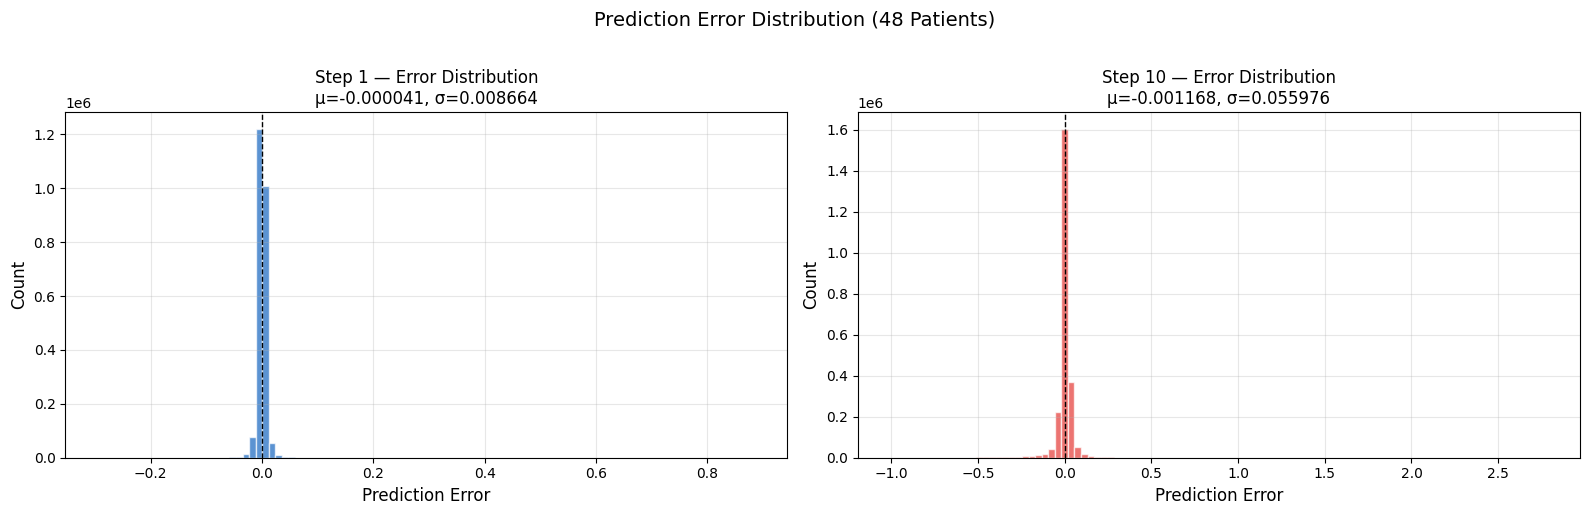

In [25]:
# ── 8.5 Error Distribution (Step 1 & 10, all patients) ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, step_idx, step_label, color in [
    (axes[0], 0, 'Step 1', '#1565C0'),
    (axes[1], HORIZON - 1, f'Step {HORIZON}', '#E53935'),
]:
    all_errors = []
    for rid in PATIENTS:
        y_true, y_pred = saved_preds[rid]
        errors = y_pred[:, step_idx] - y_true[:, step_idx]
        all_errors.append(errors)
    all_errors = np.concatenate(all_errors)

    ax.hist(all_errors, bins=100, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(x=0, color='black', linewidth=1, linestyle='--')
    ax.set_xlabel('Prediction Error', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title(f'{step_label} — Error Distribution\n'
                 f'μ={all_errors.mean():.6f}, σ={all_errors.std():.6f}', fontsize=12)
    ax.grid(alpha=0.3)

plt.suptitle(f'Prediction Error Distribution ({len(PATIENTS)} Patients)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/error_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

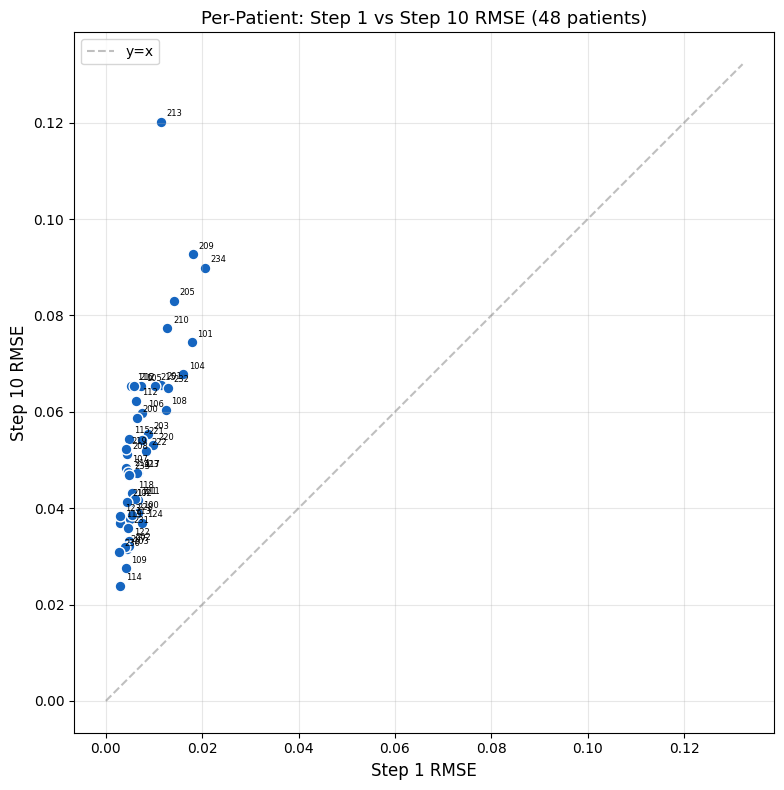

In [26]:
# ── 8.6 Step 1 vs Step 10 RMSE Scatter (all patients) ────────────────────────
step1_rmse  = [per_step_results[rid].RMSE.values[0] for rid in PATIENTS]
step10_rmse = [per_step_results[rid].RMSE.values[-1] for rid in PATIENTS]

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(step1_rmse, step10_rmse, s=60, c='#1565C0', edgecolors='white', linewidths=1)
for i, rid in enumerate(PATIENTS):
    ax.annotate(rid, (step1_rmse[i], step10_rmse[i]),
               textcoords='offset points', xytext=(4, 4), fontsize=6)

lims = [0, max(max(step1_rmse), max(step10_rmse)) * 1.1]
ax.plot(lims, lims, '--', color='grey', alpha=0.5, label='y=x')

ax.set_xlabel('Step 1 RMSE', fontsize=12)
ax.set_ylabel(f'Step {HORIZON} RMSE', fontsize=12)
ax.set_title(f'Per-Patient: Step 1 vs Step {HORIZON} RMSE ({len(PATIENTS)} patients)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/step1_vs_step10_scatter.png', dpi=200, bbox_inches='tight')
plt.show()

## 9 — Summary

In [27]:
print('\n' + '=' * 80)
print('MOGWO-OPTIMIZED TCN — FINAL EVALUATION COMPLETE (NEW_SET)')
print('=' * 80)

print(f'\nConfiguration (from MOGWO Pareto-best):')
print(f'  n_filters     = {NUM_FILTERS}')
print(f'  dropout       = {DROPOUT_RATE}')
print(f'  lr            = {LEARNING_RATE}')
print(f'  n_blocks      = {NUM_BLOCKS} (fixed, RF=29)')
print(f'  kernel_size   = {KERNEL_SIZE} (fixed)')
print(f'  batch_size    = {BATCH_SIZE} (fixed)')

print(f'\nResults (H={HORIZON}, {len(PATIENTS)} patients — ALL MIT-BIH):')
print(f'  Mean RMSE     = {df_results.RMSE.mean():.6f} ± {df_results.RMSE.std():.6f}')
print(f'  Mean MAE      = {df_results.MAE.mean():.6f} ± {df_results.MAE.std():.6f}')
print(f'  Mean R²       = {df_results.R2.mean():.4f} ± {df_results.R2.std():.4f}')

print(f'\nvs Old GWO (256f, 4blk) — {len(overlap_patients)} overlapping patients:')
print(f'  RMSE  : {rmse_old:.6f} → {rmse_new:.6f} ({(rmse_new-rmse_old)/rmse_old*100:+.1f}%)')
print(f'  R²    : {r2_old:.4f} → {r2_new:.4f} ({(r2_new-r2_old)/r2_old*100:+.2f}%)')
print(f'  Wins  : {wins}/{len(overlap_patients)} patients')
print(f'  Params: ~370K → ~68K (81% fewer)')

print(f'\nOutputs saved to {OUT_DIR}/:')
print(f'  {os.path.basename(CSV_NAME)}')
print(f'  {os.path.basename(PLOT_DIR)}/ (all plots)')
print('=' * 80)


MOGWO-OPTIMIZED TCN — FINAL EVALUATION COMPLETE (NEW_SET)

Configuration (from MOGWO Pareto-best):
  n_filters     = 128
  dropout       = 0.131
  lr            = 0.00451
  n_blocks      = 3 (fixed, RF=29)
  kernel_size   = 3 (fixed)
  batch_size    = 128 (fixed)

Results (H=10, 48 patients — ALL MIT-BIH):
  Mean RMSE     = 0.033069 ± 0.012772
  Mean MAE      = 0.014776 ± 0.005770
  Mean R²       = 0.8865 ± 0.0794

vs Old GWO (256f, 4blk) — 21 overlapping patients:
  RMSE  : 0.029703 → 0.029672 (-0.1%)
  R²    : 0.9020 → 0.9040 (+0.22%)
  Wins  : 4/21 patients
  Params: ~370K → ~68K (81% fewer)

Outputs saved to /kaggle/working/:
  tcn_mo_mogwo_new_set_results.csv
  plots_new_set/ (all plots)
